# Secondary fit-capacity diagnostic

This notebook tests whether the secondary-state data can be fitted when parameter identifiability and transferability are relaxed.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT / 'fermentation_model').exists():
    ROOT = ROOT / 'fermentation_model'
RESULTS = ROOT / 'results/secondary_fit_capacity'
display(pd.read_csv(RESULTS / 'fit_capacity_summary.csv'))
display(pd.read_csv(RESULTS / 'fit_capacity_aggregate_metrics.csv'))
display(pd.read_csv(RESULTS / 'batch_all_o2free_parameter_spread.csv'))

,fit_label,success,status,message,nfev,n_parameters_fit,n_batches,n_residuals,initial_wsse,final_wsse,wsse_per_residual
0,global_v2_reduced_o2fixed,True,NaN,loaded from v2 reduced evaluation,NaN,7,27,588,NaN,5754.094324,9.785875
1,medium_v2_reduced_o2fixed_historical_vl3,True,2.0,`ftol` termination condition is satisfied.,25.0,7,8,251,2503.146909,2418.629353,9.635974
2,medium_v2_reduced_o2fixed_natural,True,2.0,`ftol` termination condition is satisfied.,9.0,7,9,253,2647.608011,1949.821824,7.706806
3,medium_v2_reduced_o2fixed_synthetic,True,2.0,`ftol` termination condition is satisfied.,16.0,7,10,87,603.339404,365.770226,4.204255
4,batch_v2_reduced_o2fixed_historical_vl3_25026,True,2.0,`ftol` termination condition is satisfied.,44.0,7,1,11,123.343432,6.333158,0.575742
5,batch_v2_all_o2free_historical_vl3_25026,True,2.0,`ftol` termination condition is satisfied.,46.0,10,1,11,123.343432,4.752188,0.432017
6,batch_v2_reduced_o2fixed_historical_vl3_25027,True,2.0,`ftol` termination condition is satisfied.,22.0,7,1,13,260.454715,61.414837,4.724218
7,batch_v2_all_o2free_historical_vl3_25027,False,0.0,The maximum number of function evaluations is ...,80.0,10,1,13,260.454715,32.860283,2.527714
8,batch_v2_reduced_o2fixed_historical_vl3_25085,True,2.0,`ftol` termination condition is satisfied.,19.0,7,1,34,153.521077,26.888750,0.790846
9,batch_v2_all_o2free_historical_vl3_25085,True,2.0,`ftol` termination condition is satisfied.,42.0,10,1,34,153.521077,25.771597,0.757988


,fit_label,state,n_obs,wsse,wsse_per_obs,rmse_weighted_mean,mae_weighted_mean
0,batch_v2_all_o2free,AcAld,193,425.565496,2.205003,11.248567,7.896997
1,batch_v2_all_o2free,Acetate,50,59.117417,1.182348,0.036032,0.027726
2,batch_v2_all_o2free,O2,32,110.458314,3.451822,0.370944,0.320975
3,batch_v2_all_o2free,Pyr,313,362.751962,1.158952,5.896053,4.540202
4,batch_v2_reduced_o2fixed,AcAld,193,685.190202,3.550208,13.691247,9.945551
5,batch_v2_reduced_o2fixed,Acetate,50,99.274332,1.985487,0.046007,0.035426
6,batch_v2_reduced_o2fixed,O2,32,98.129373,3.066543,0.345615,0.297618
7,batch_v2_reduced_o2fixed,Pyr,313,466.147097,1.489288,6.844140,5.256607
8,global_v2_reduced_o2fixed,AcAld,193,2686.893739,13.921729,28.462374,23.615169
9,global_v2_reduced_o2fixed,Acetate,50,677.116367,13.542327,0.127543,0.104960


,fit_label,parameter,n,min,median,max,fold_range,robust_cv
0,batch_v2_all_o2free,kPyrS_N,27,0.000100,0.005297,2.438536,24385.361169,195.061154
1,batch_v2_all_o2free,kPyrO2,27,0.000100,1.180568,9.982827,99828.270120,1.522136
2,batch_v2_all_o2free,kPyrDrain,27,0.001019,0.007353,0.148551,145.777141,1.171069
3,batch_v2_all_o2free,kAldS_N,27,0.000239,2.168405,10.000000,41880.141192,1.477468
4,batch_v2_all_o2free,kAldRed,27,0.000010,0.000028,1.976955,197695.480865,23.380161
5,batch_v2_all_o2free,kAcAld,27,0.000043,0.004115,1.693591,39686.346153,13.477082
6,batch_v2_all_o2free,kAcStress,27,0.000001,0.002616,0.468247,468247.162115,0.565412
7,batch_v2_all_o2free,qO2,27,0.000104,0.098965,0.359725,3463.253890,0.938347
8,batch_v2_all_o2free,kLaO2,27,0.000010,0.000590,0.108340,10834.011913,14.168084
9,batch_v2_all_o2free,O2sat,27,0.500000,2.284356,8.000000,15.999998,3.255446


## Batch-Level Metrics

In [2]:
metrics = pd.read_csv(RESULTS / 'fit_capacity_state_metrics.csv')
display(metrics.sort_values(['fit_label','medium','batch','state']).head(80))

,fit_label,medium,batch,state,n_obs,wsse,wsse_per_obs,rmse,mae,obs_median,obs_range
144,batch_v2_all_o2free,historical_vl3,25026,Pyr,11,4.752188,0.432017,3.943681,3.321558,33.000,43.00
145,batch_v2_all_o2free,historical_vl3,25027,Pyr,13,32.860283,2.527714,9.539272,8.090650,36.000,36.00
147,batch_v2_all_o2free,historical_vl3,25085,AcAld,17,17.917725,1.053984,8.213097,6.481211,178.000,82.00
146,batch_v2_all_o2free,historical_vl3,25085,Pyr,17,7.853872,0.461992,4.078202,3.454721,55.000,49.00
149,batch_v2_all_o2free,historical_vl3,25086,AcAld,17,12.212711,0.718395,6.780654,5.247472,184.000,39.00
...,...,...,...,...,...,...,...,...,...,...,...
120,batch_v2_reduced_o2fixed,natural,LAB008,Pyr,13,7.651541,0.588580,4.603138,3.871875,21.000,42.00
125,batch_v2_reduced_o2fixed,natural,LAB009,AcAld,12,77.807784,6.483982,20.370931,15.452511,93.000,123.00
126,batch_v2_reduced_o2fixed,natural,LAB009,Acetate,12,36.543120,3.045260,0.061077,0.048596,0.320,0.32
127,batch_v2_reduced_o2fixed,natural,LAB009,O2,10,45.349548,4.534955,0.425909,0.379326,0.585,1.35


## Fit-Capacity Plots

secondary_fit_capacity_historical_vl3_25026.png


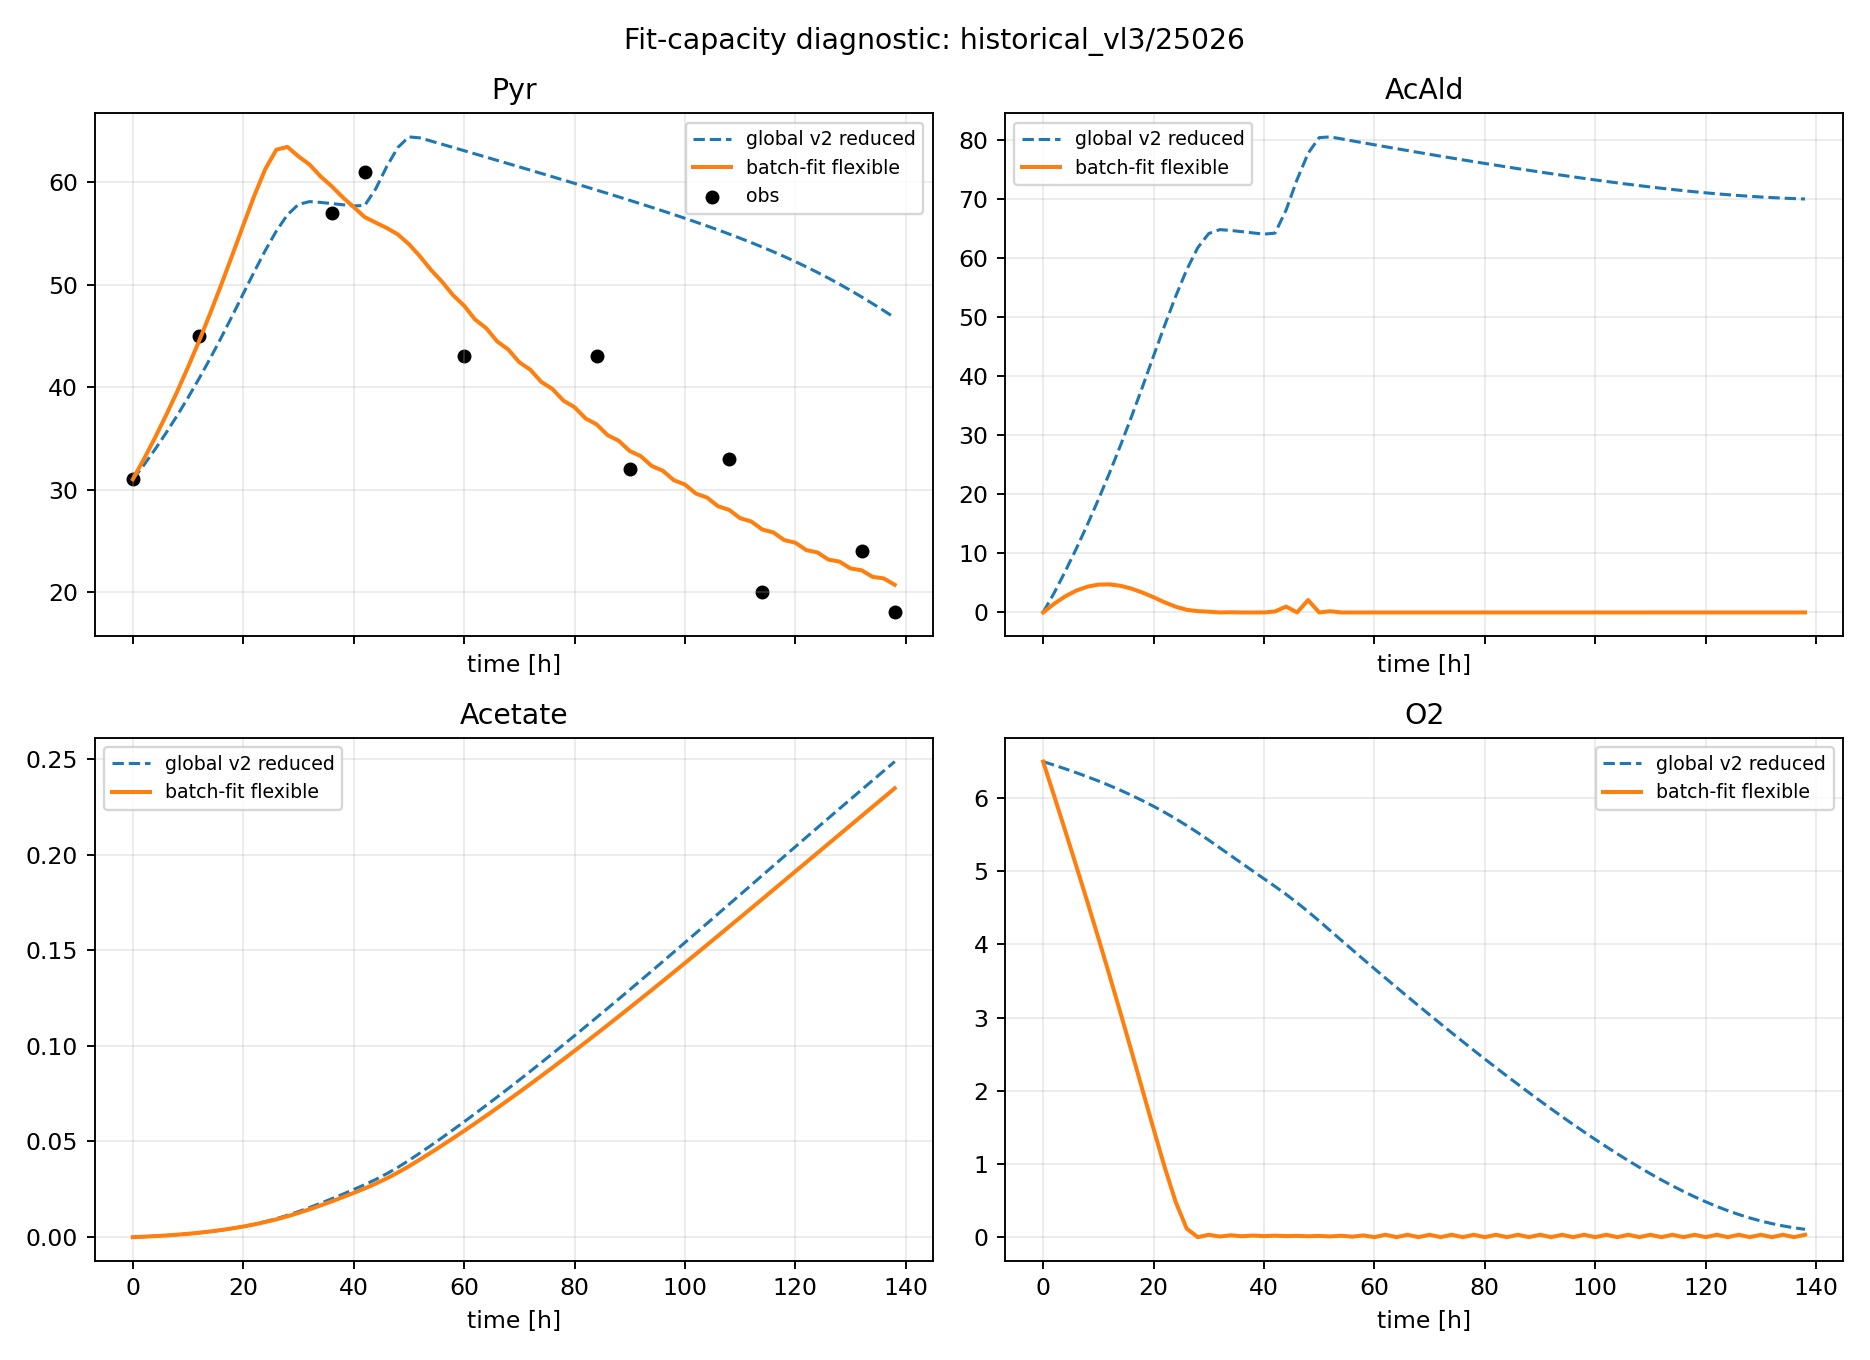

secondary_fit_capacity_historical_vl3_25027.png


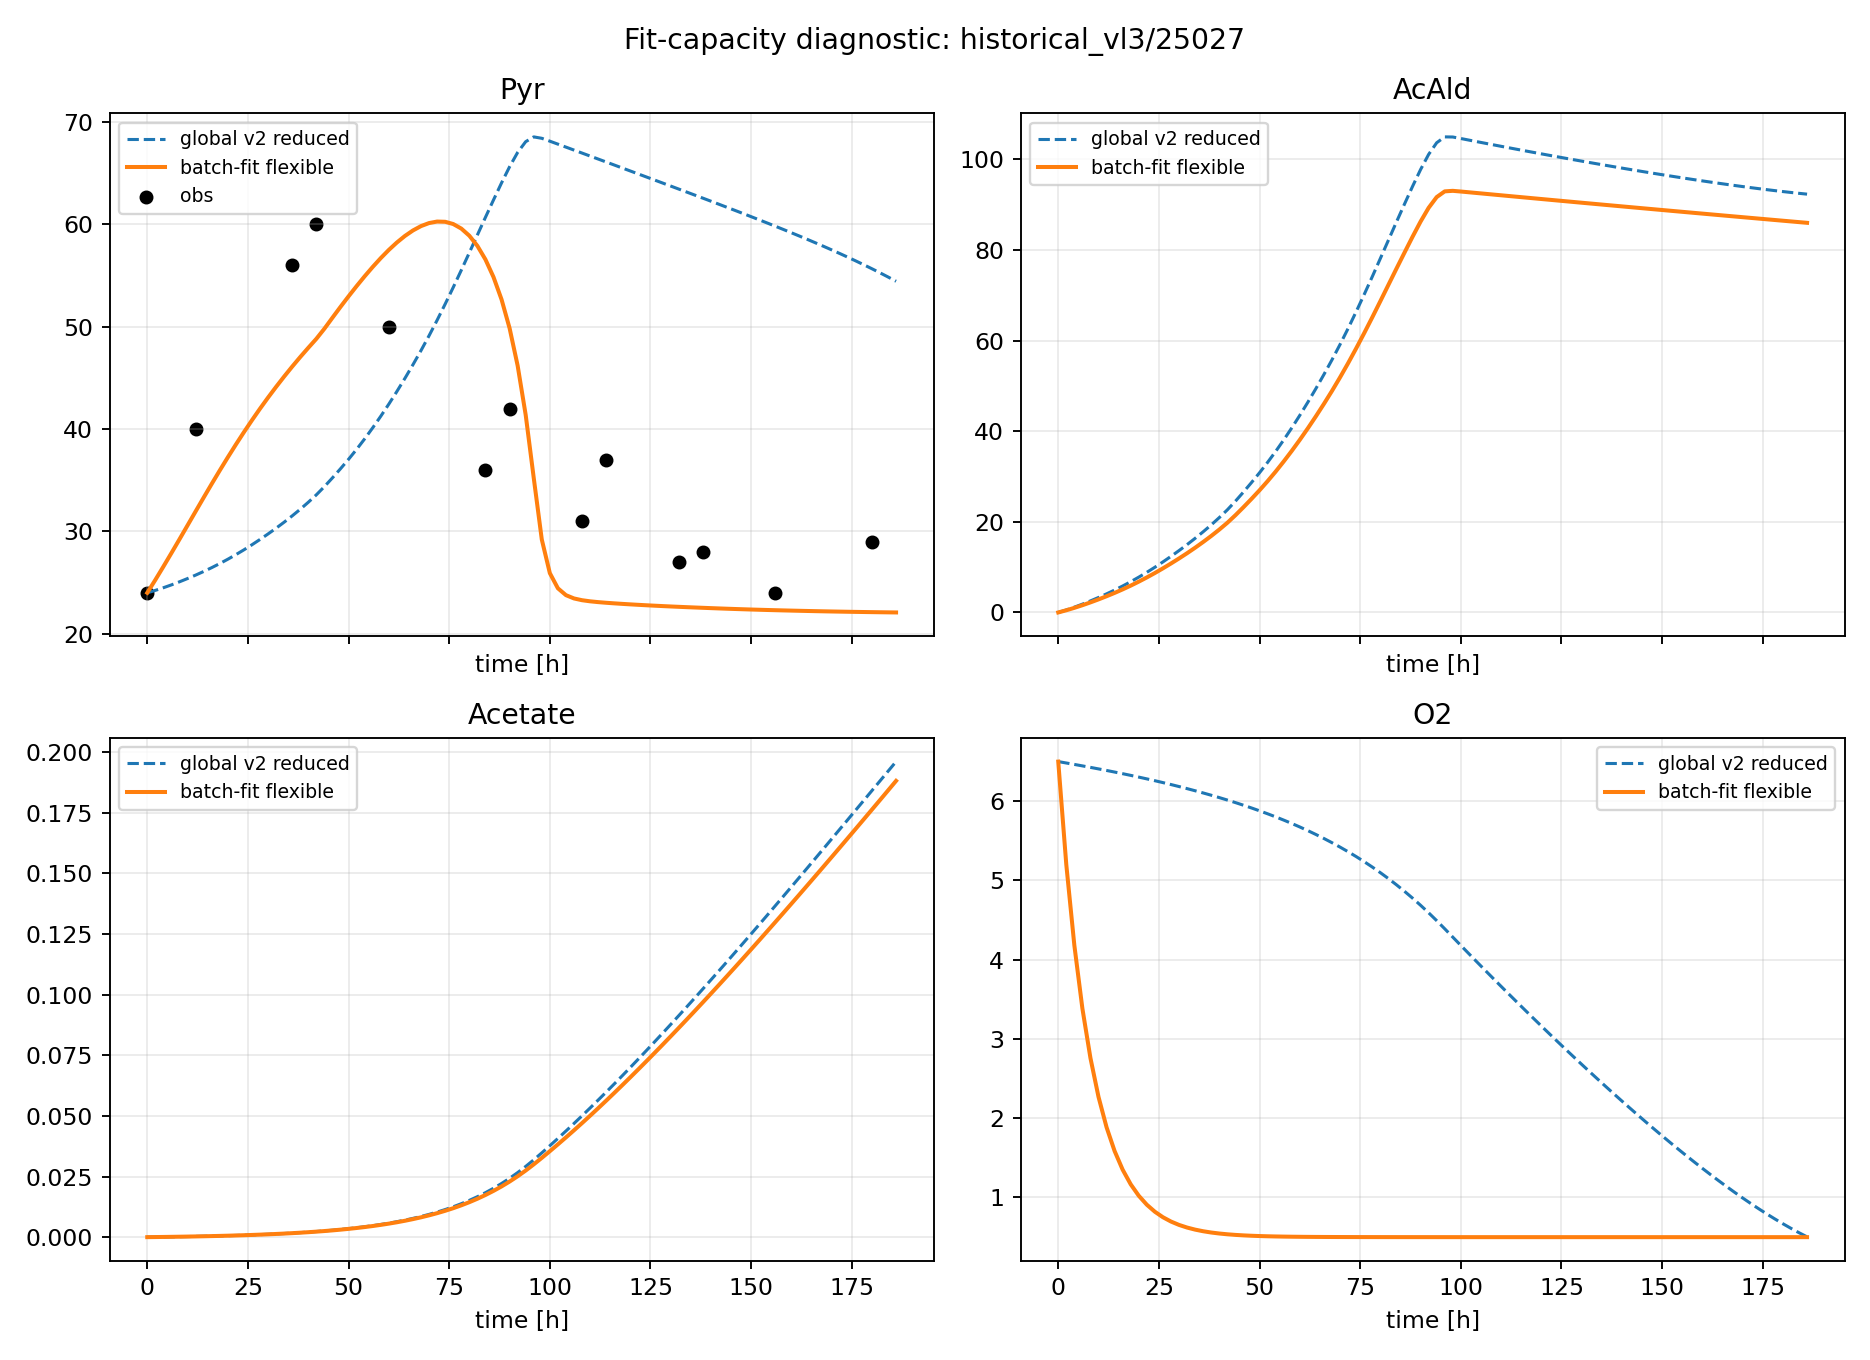

secondary_fit_capacity_historical_vl3_25085.png


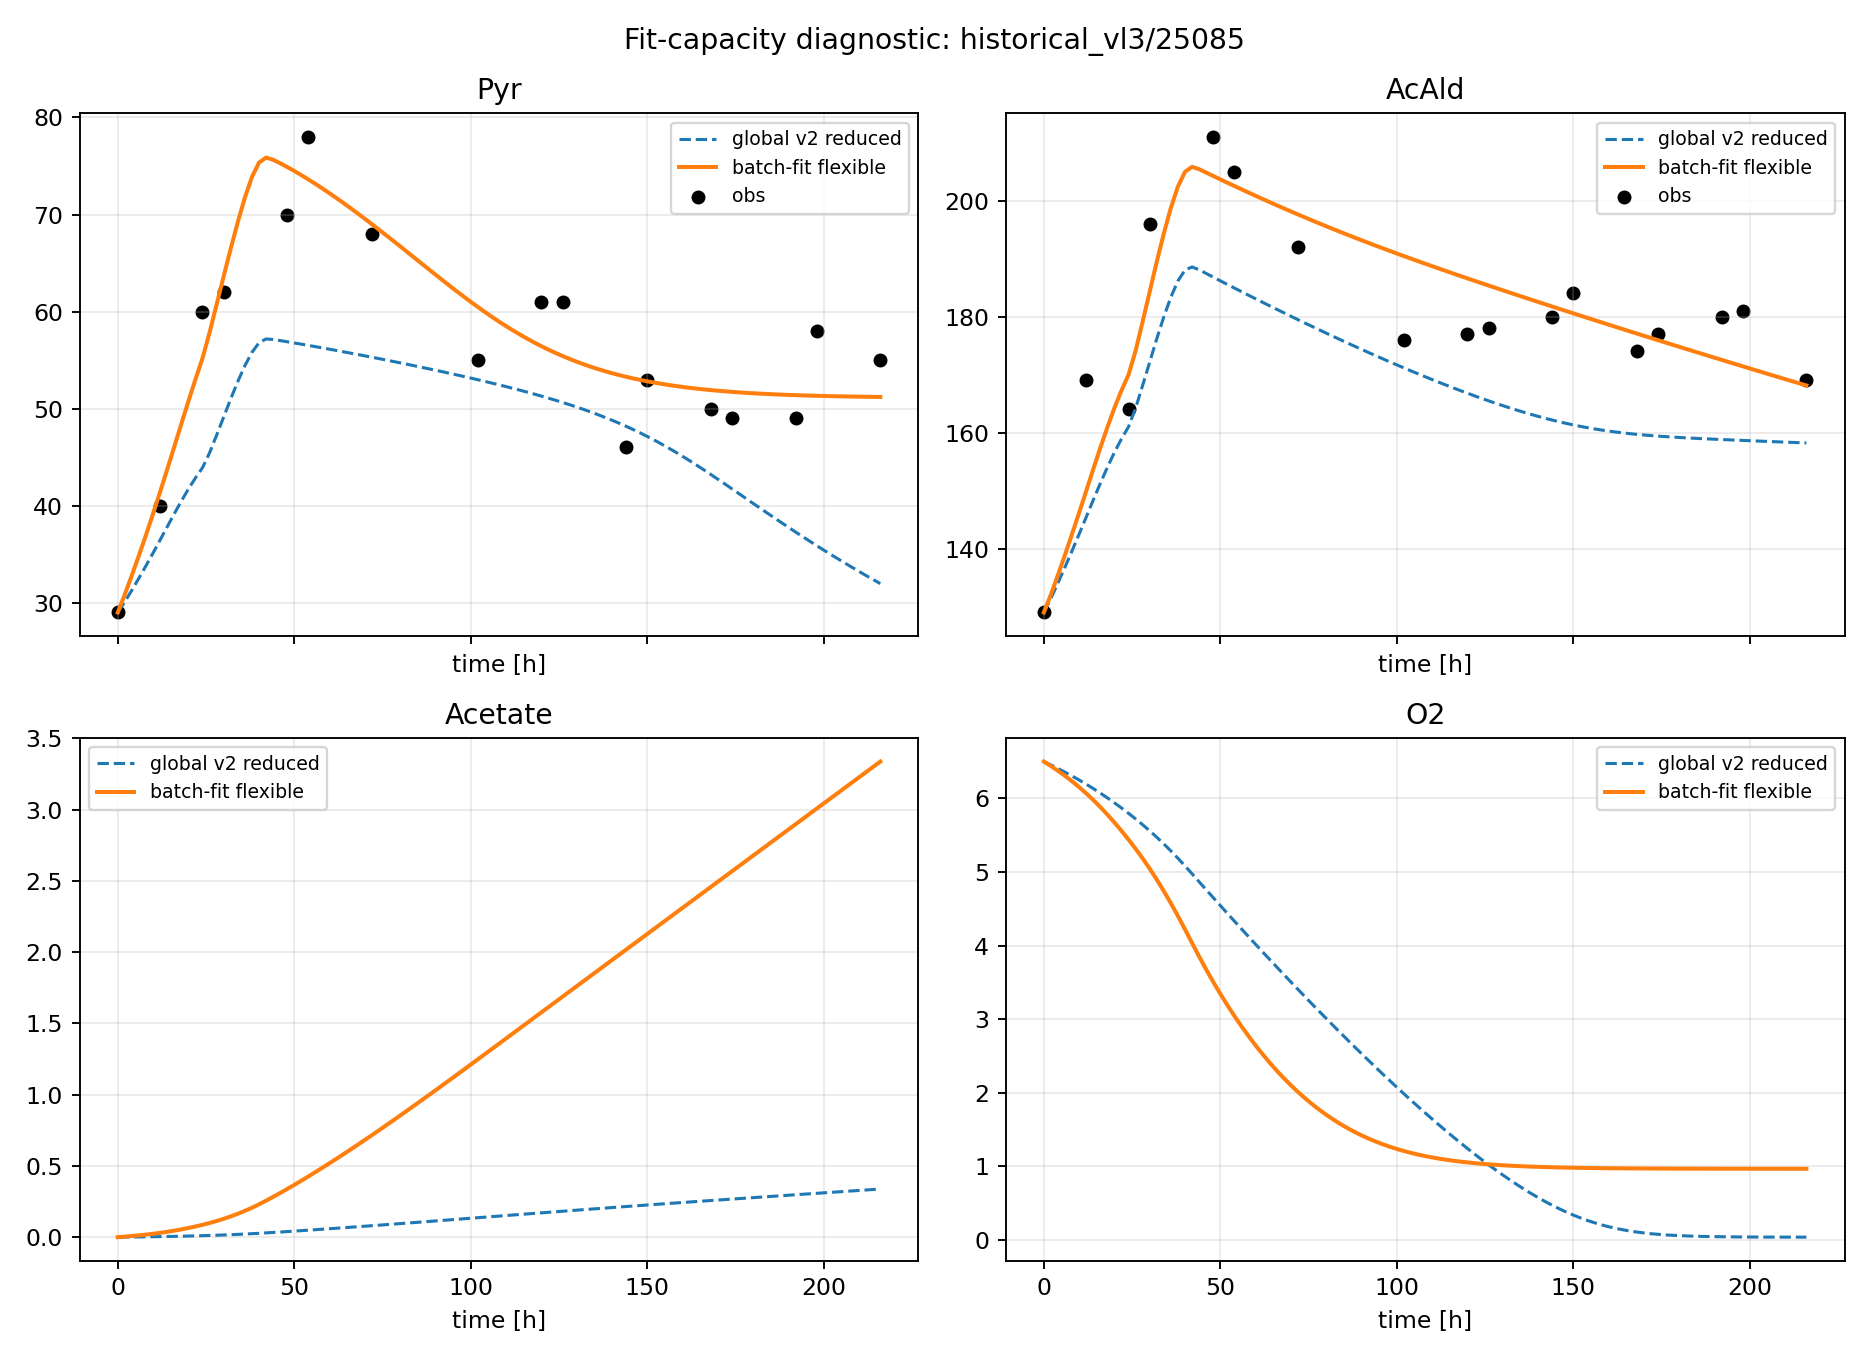

secondary_fit_capacity_historical_vl3_25086.png


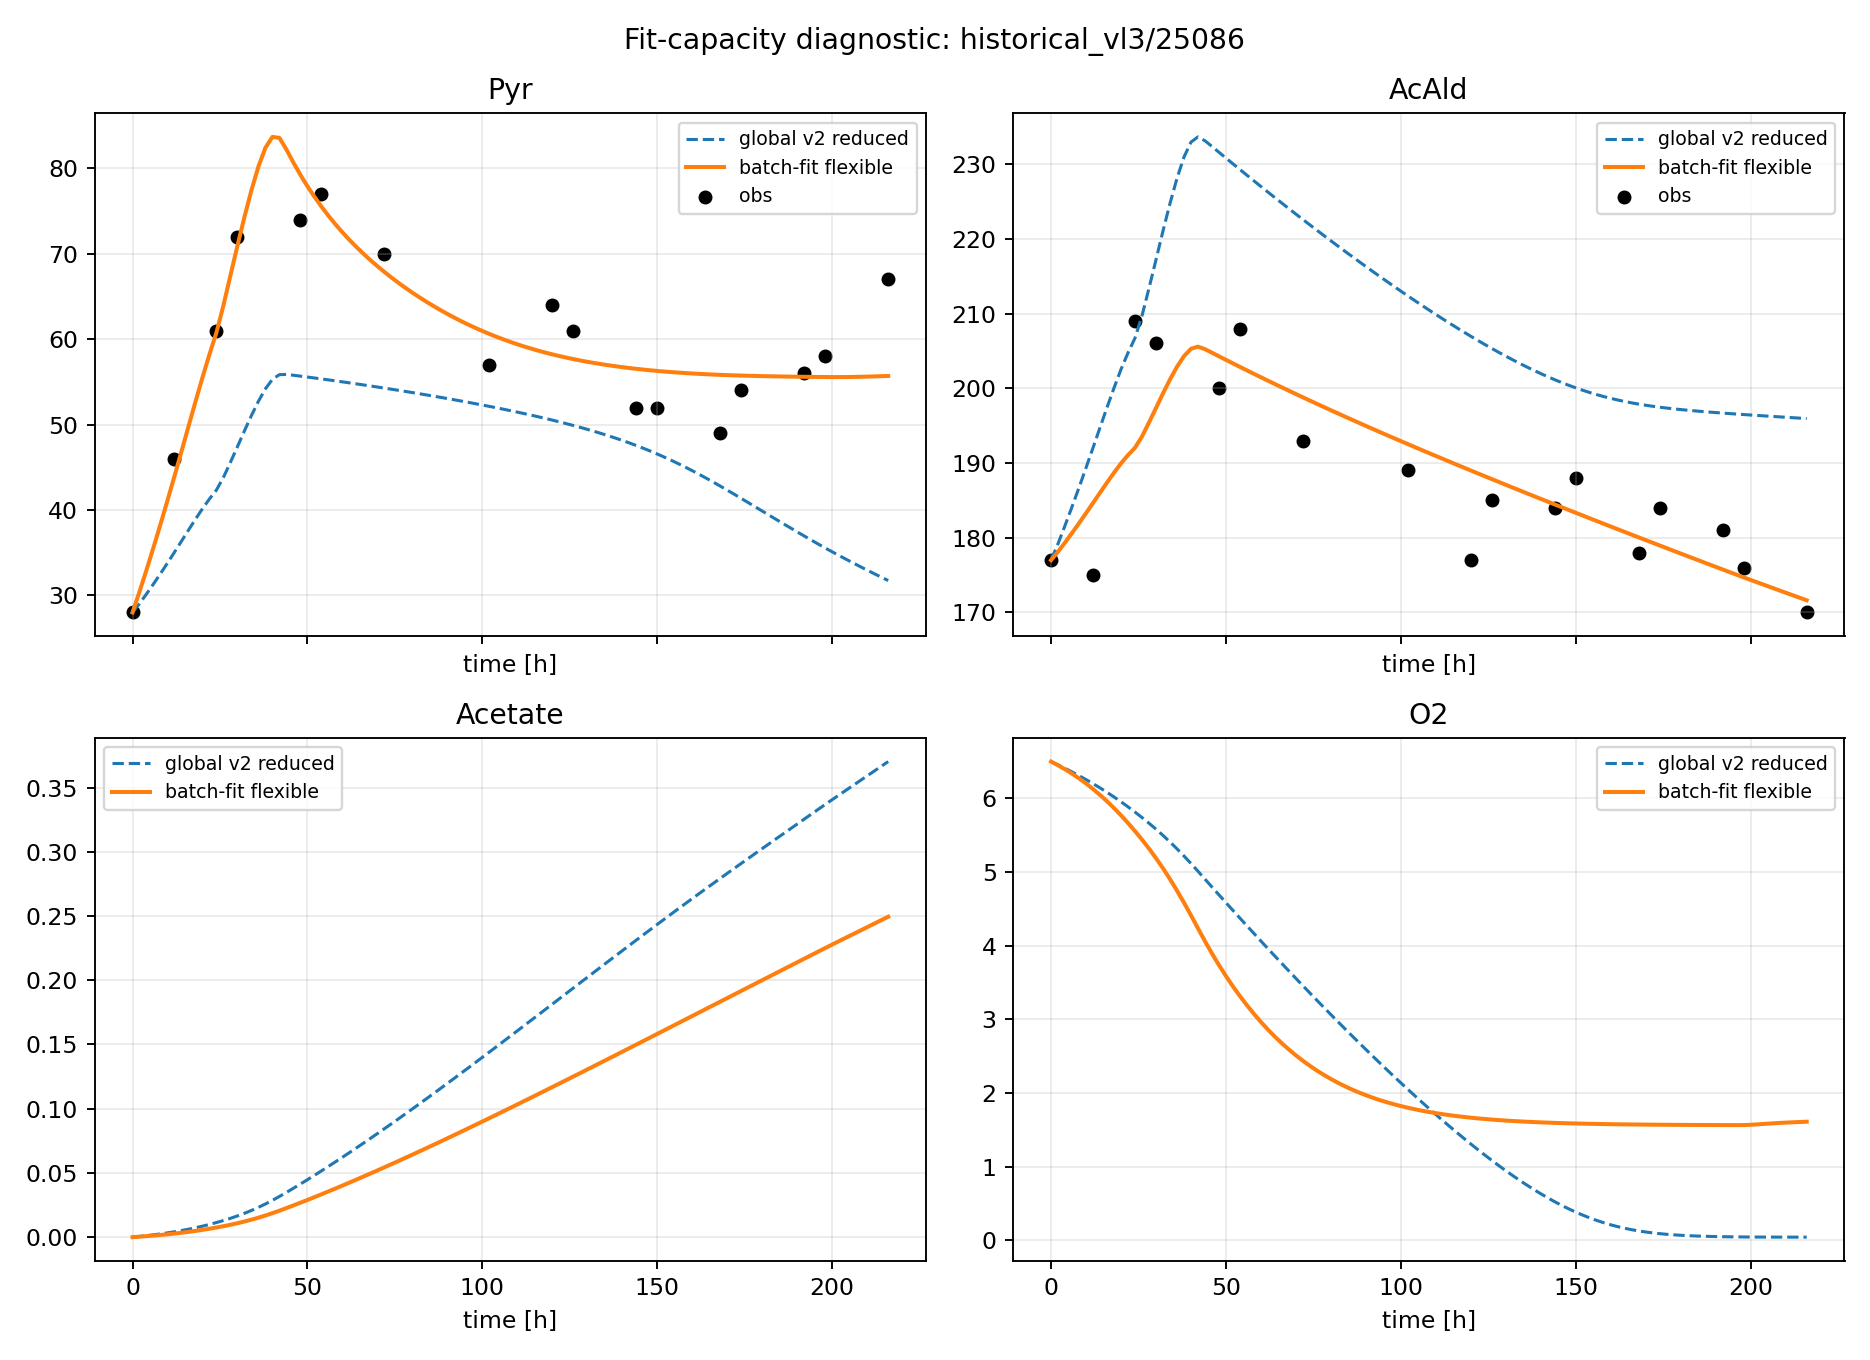

secondary_fit_capacity_historical_vl3_25150.png


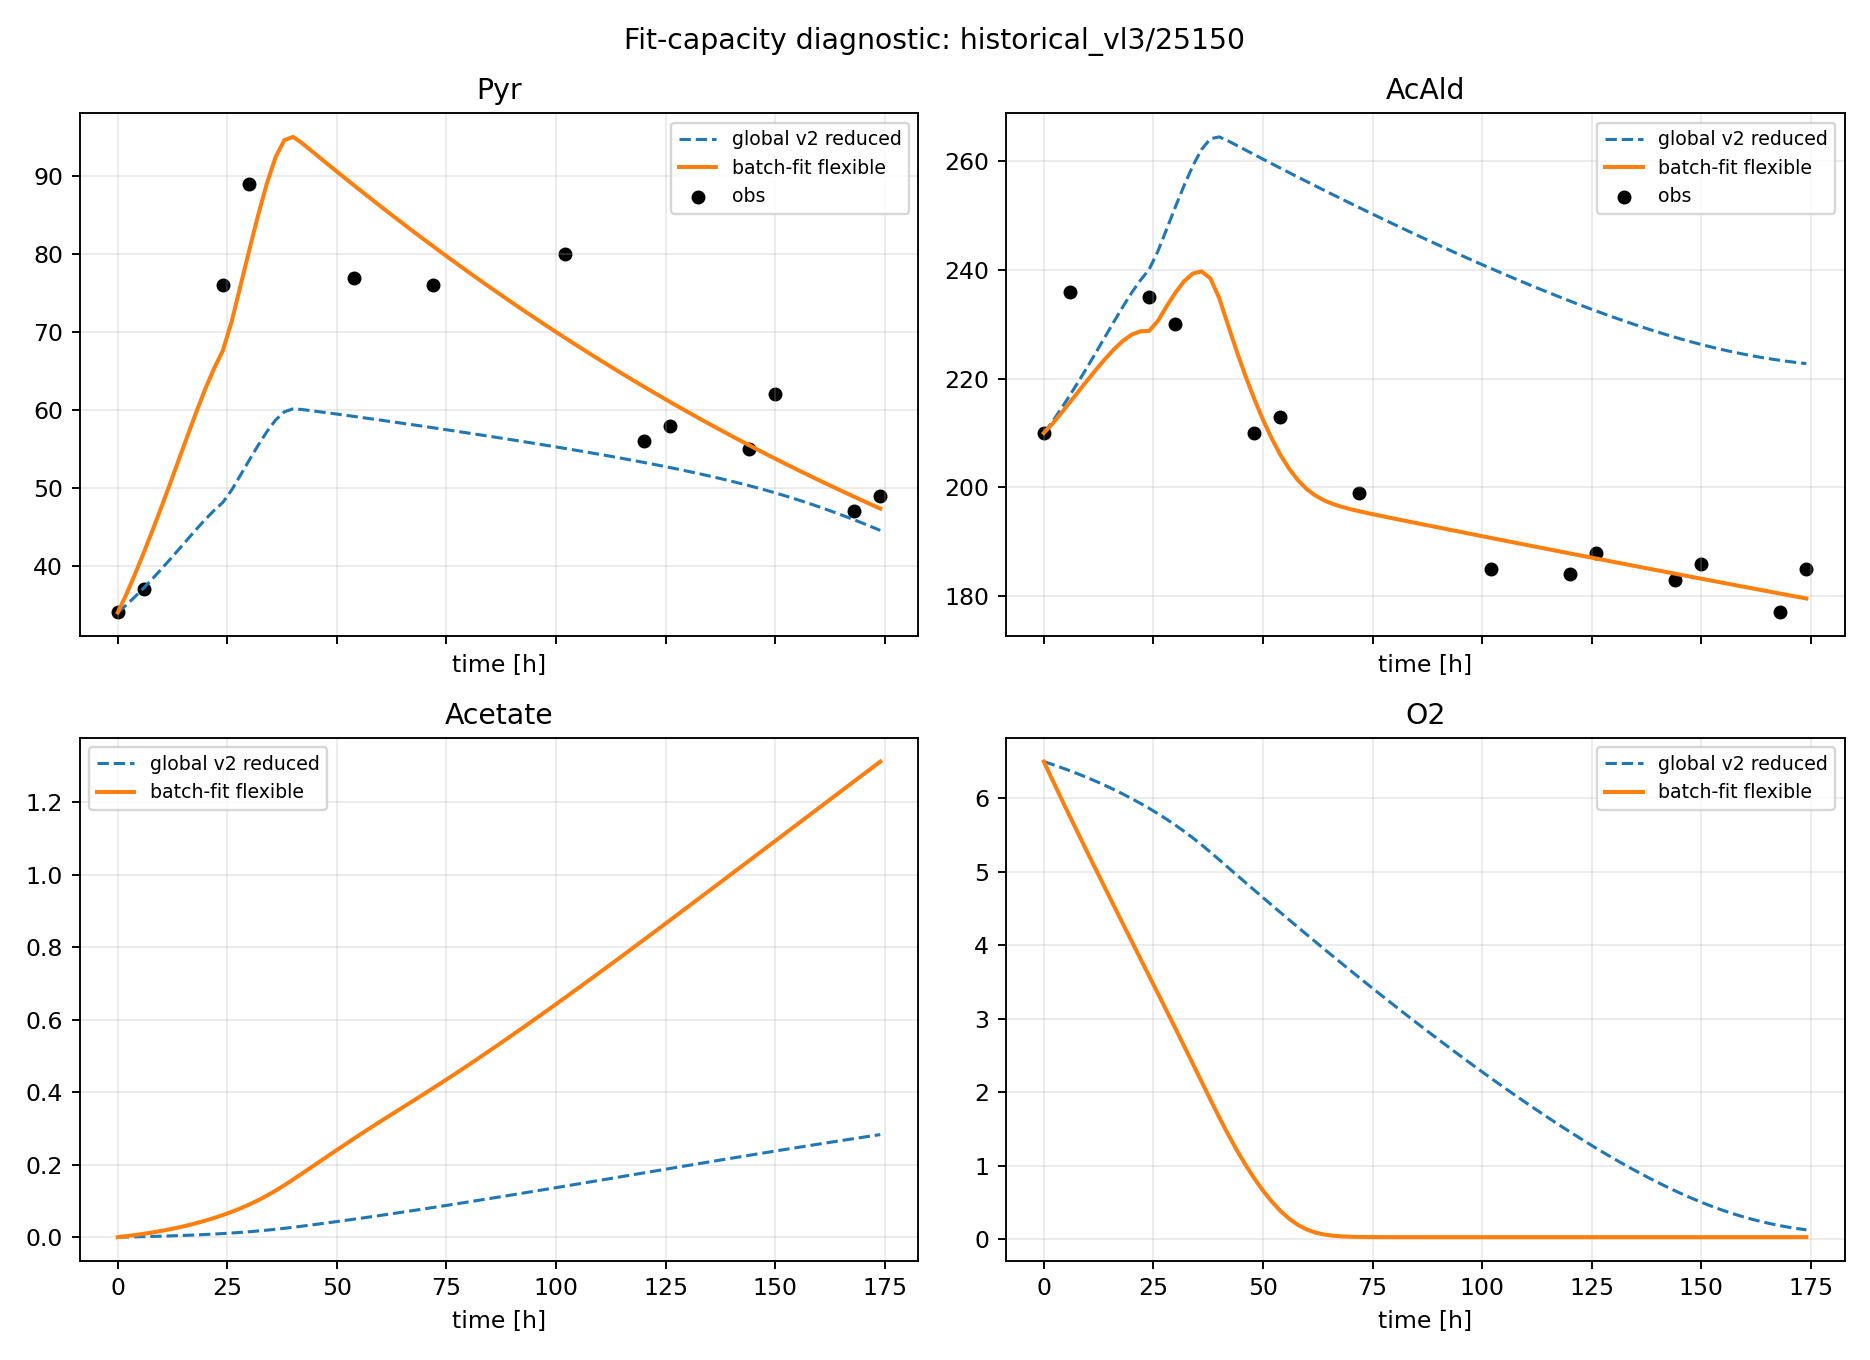

secondary_fit_capacity_historical_vl3_25151.png


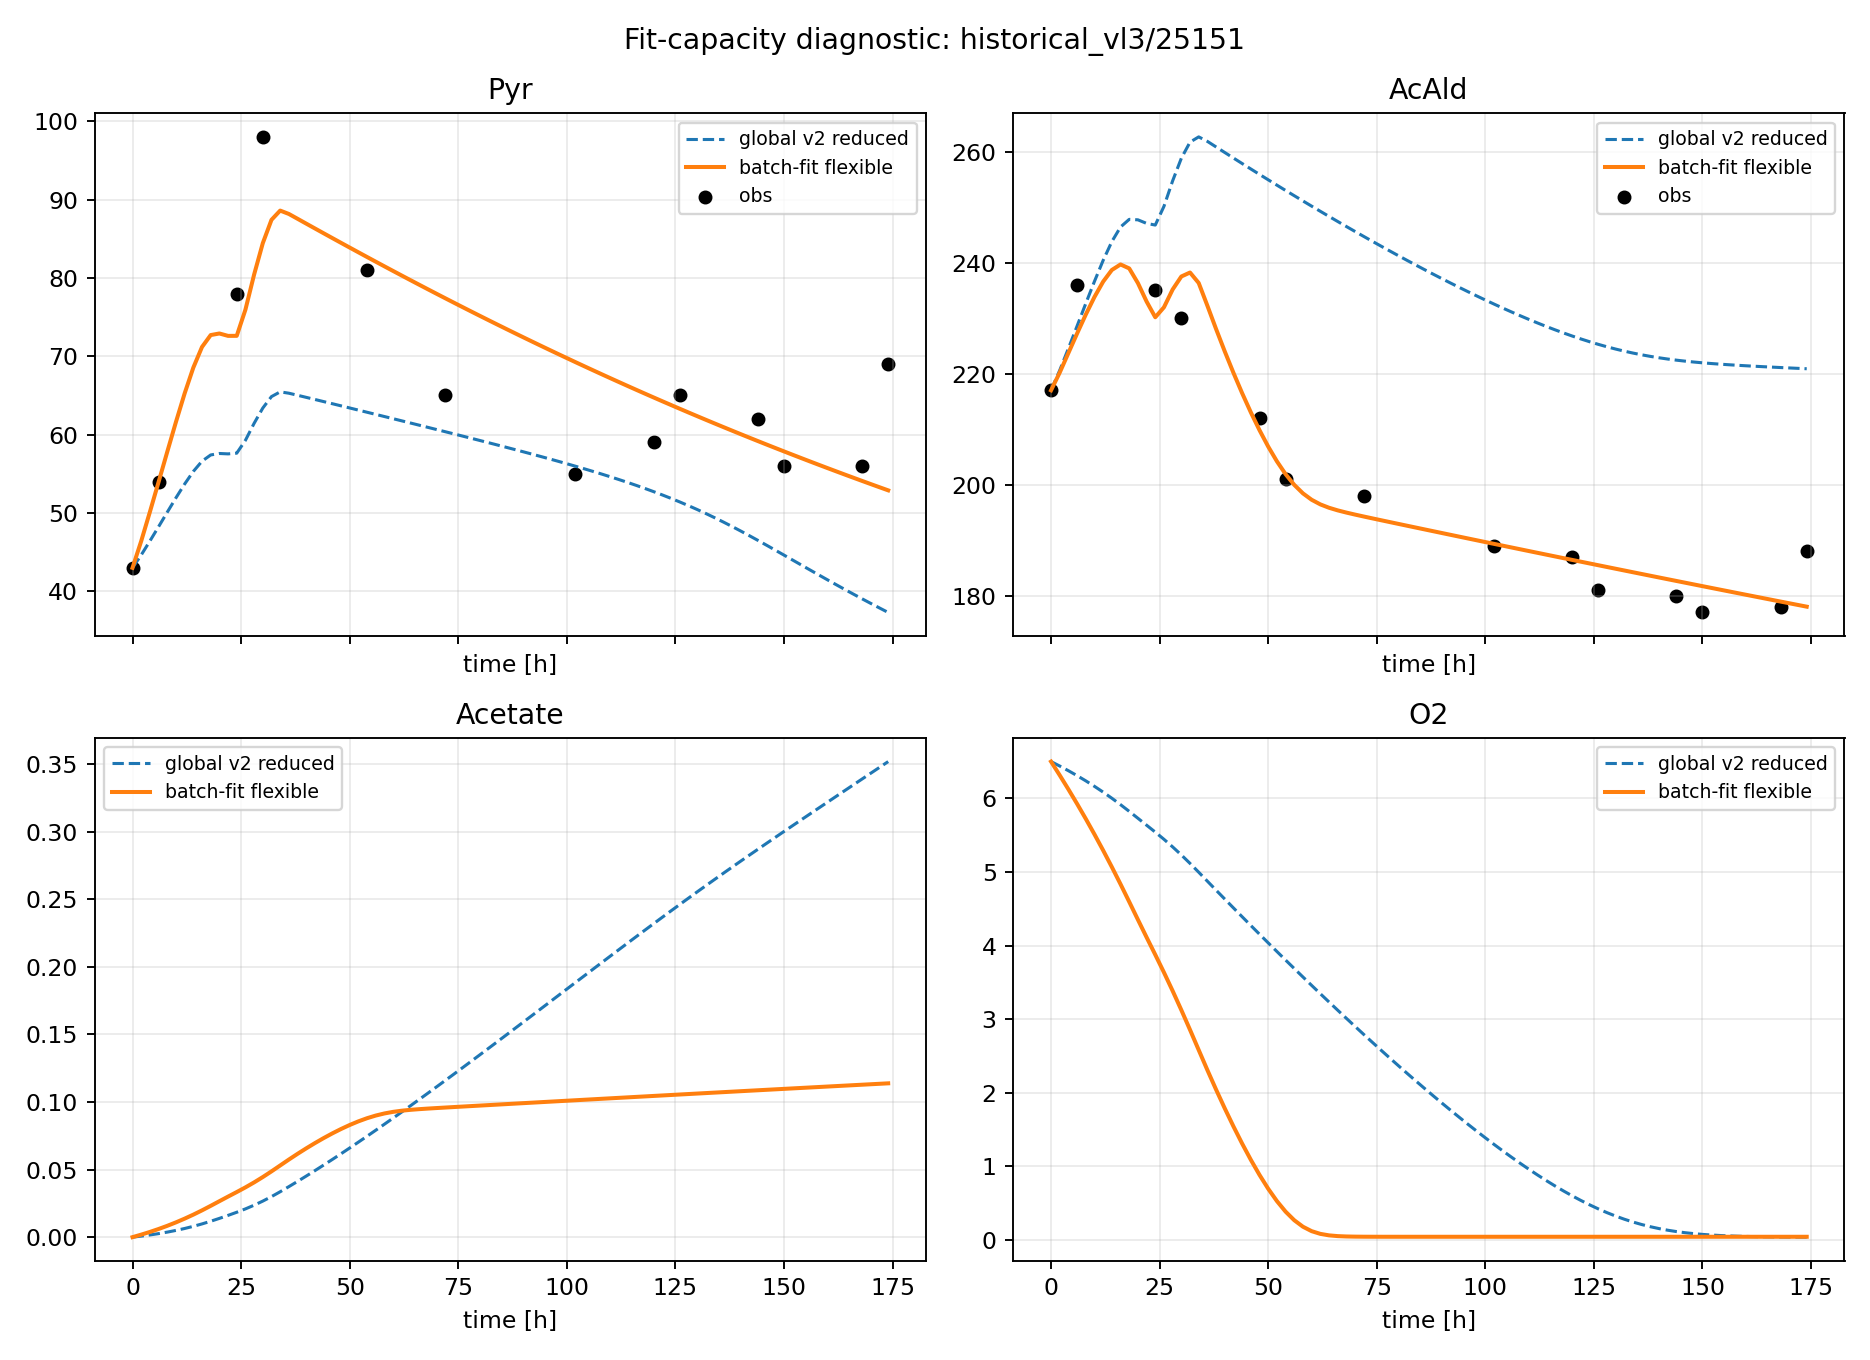

secondary_fit_capacity_historical_vl3_25170.png


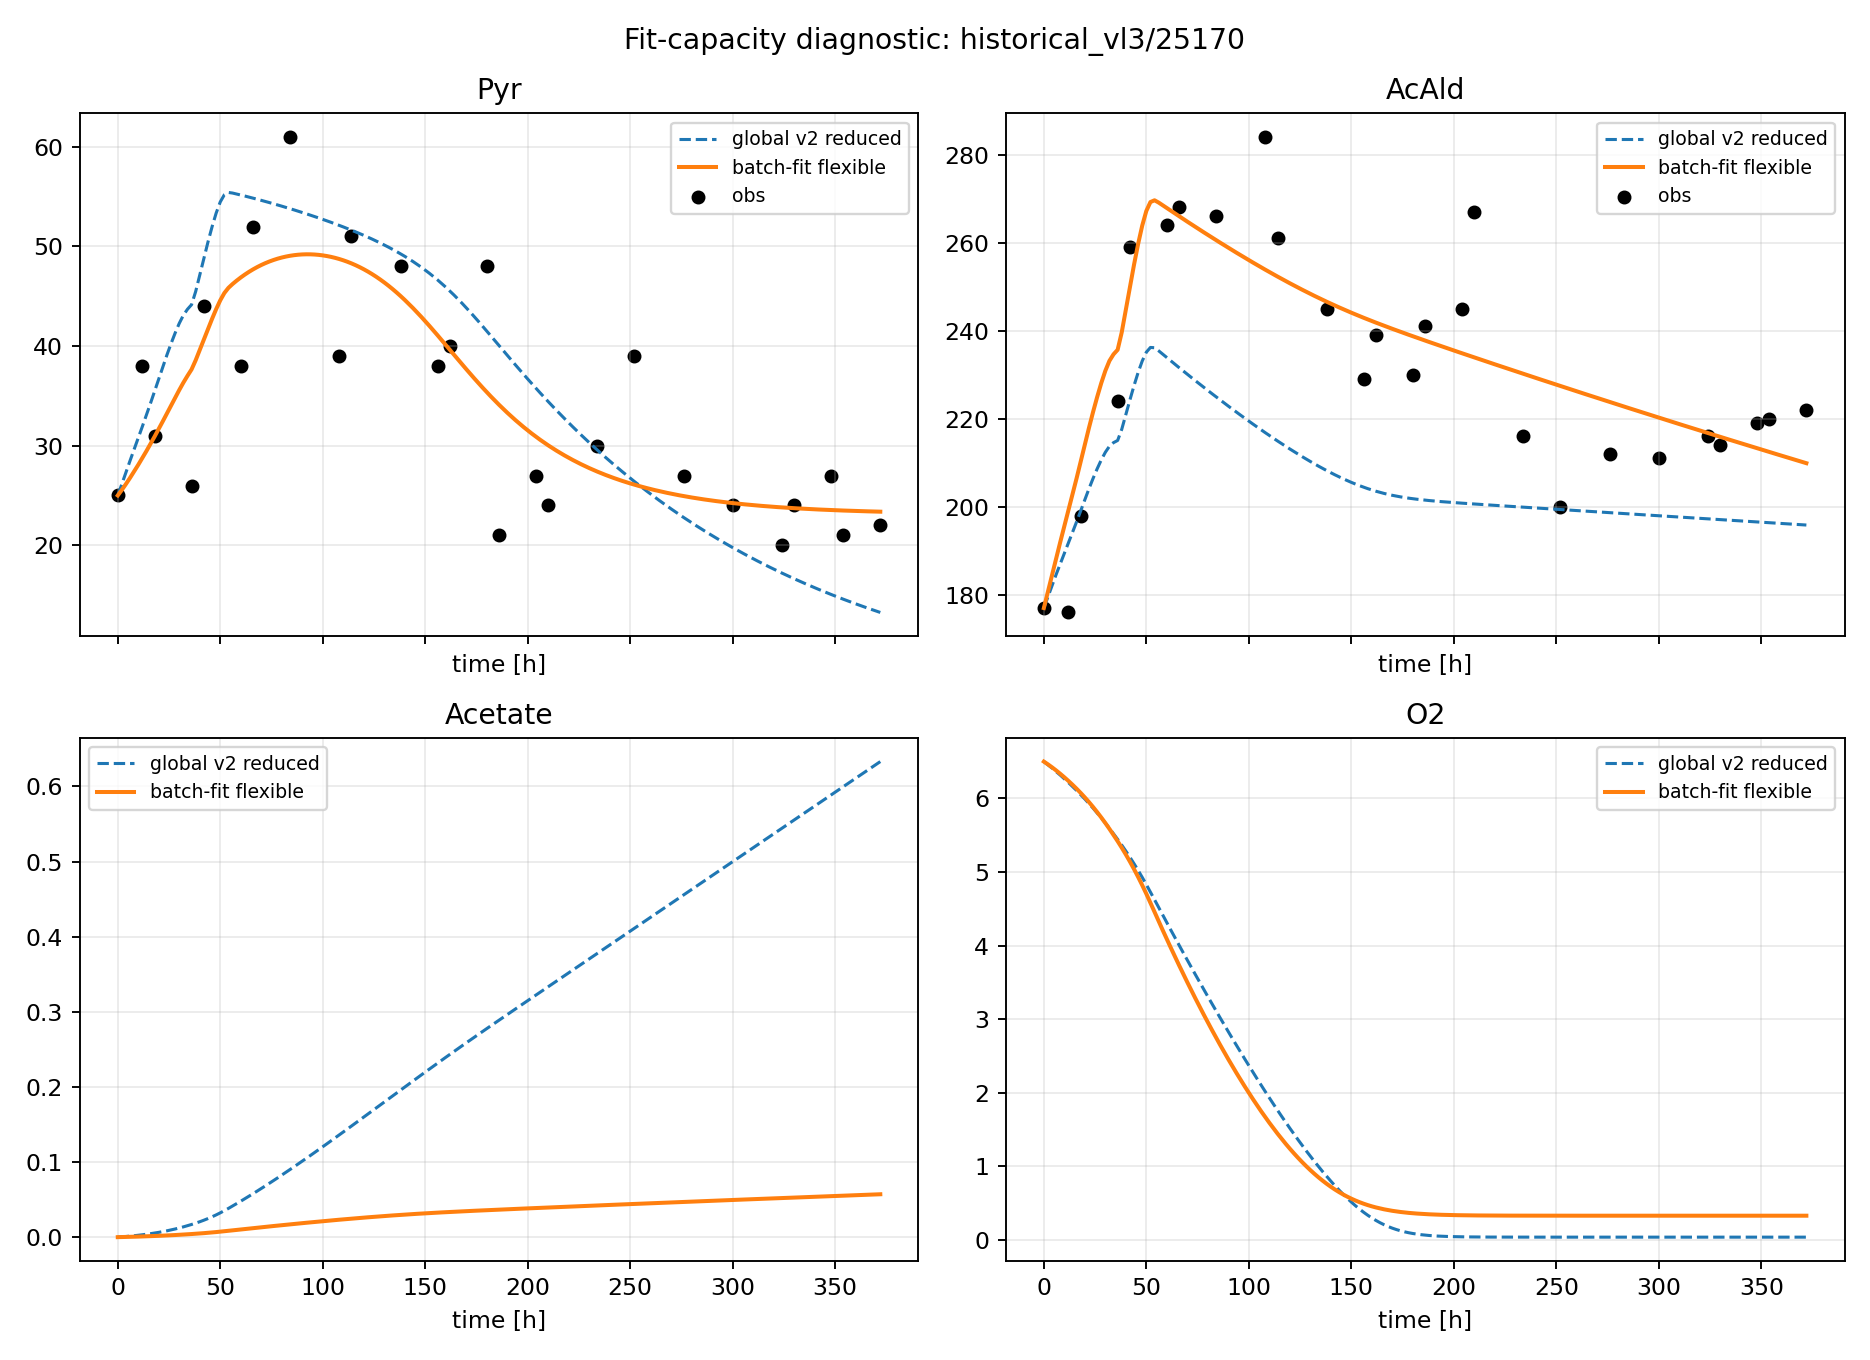

secondary_fit_capacity_historical_vl3_25171.png


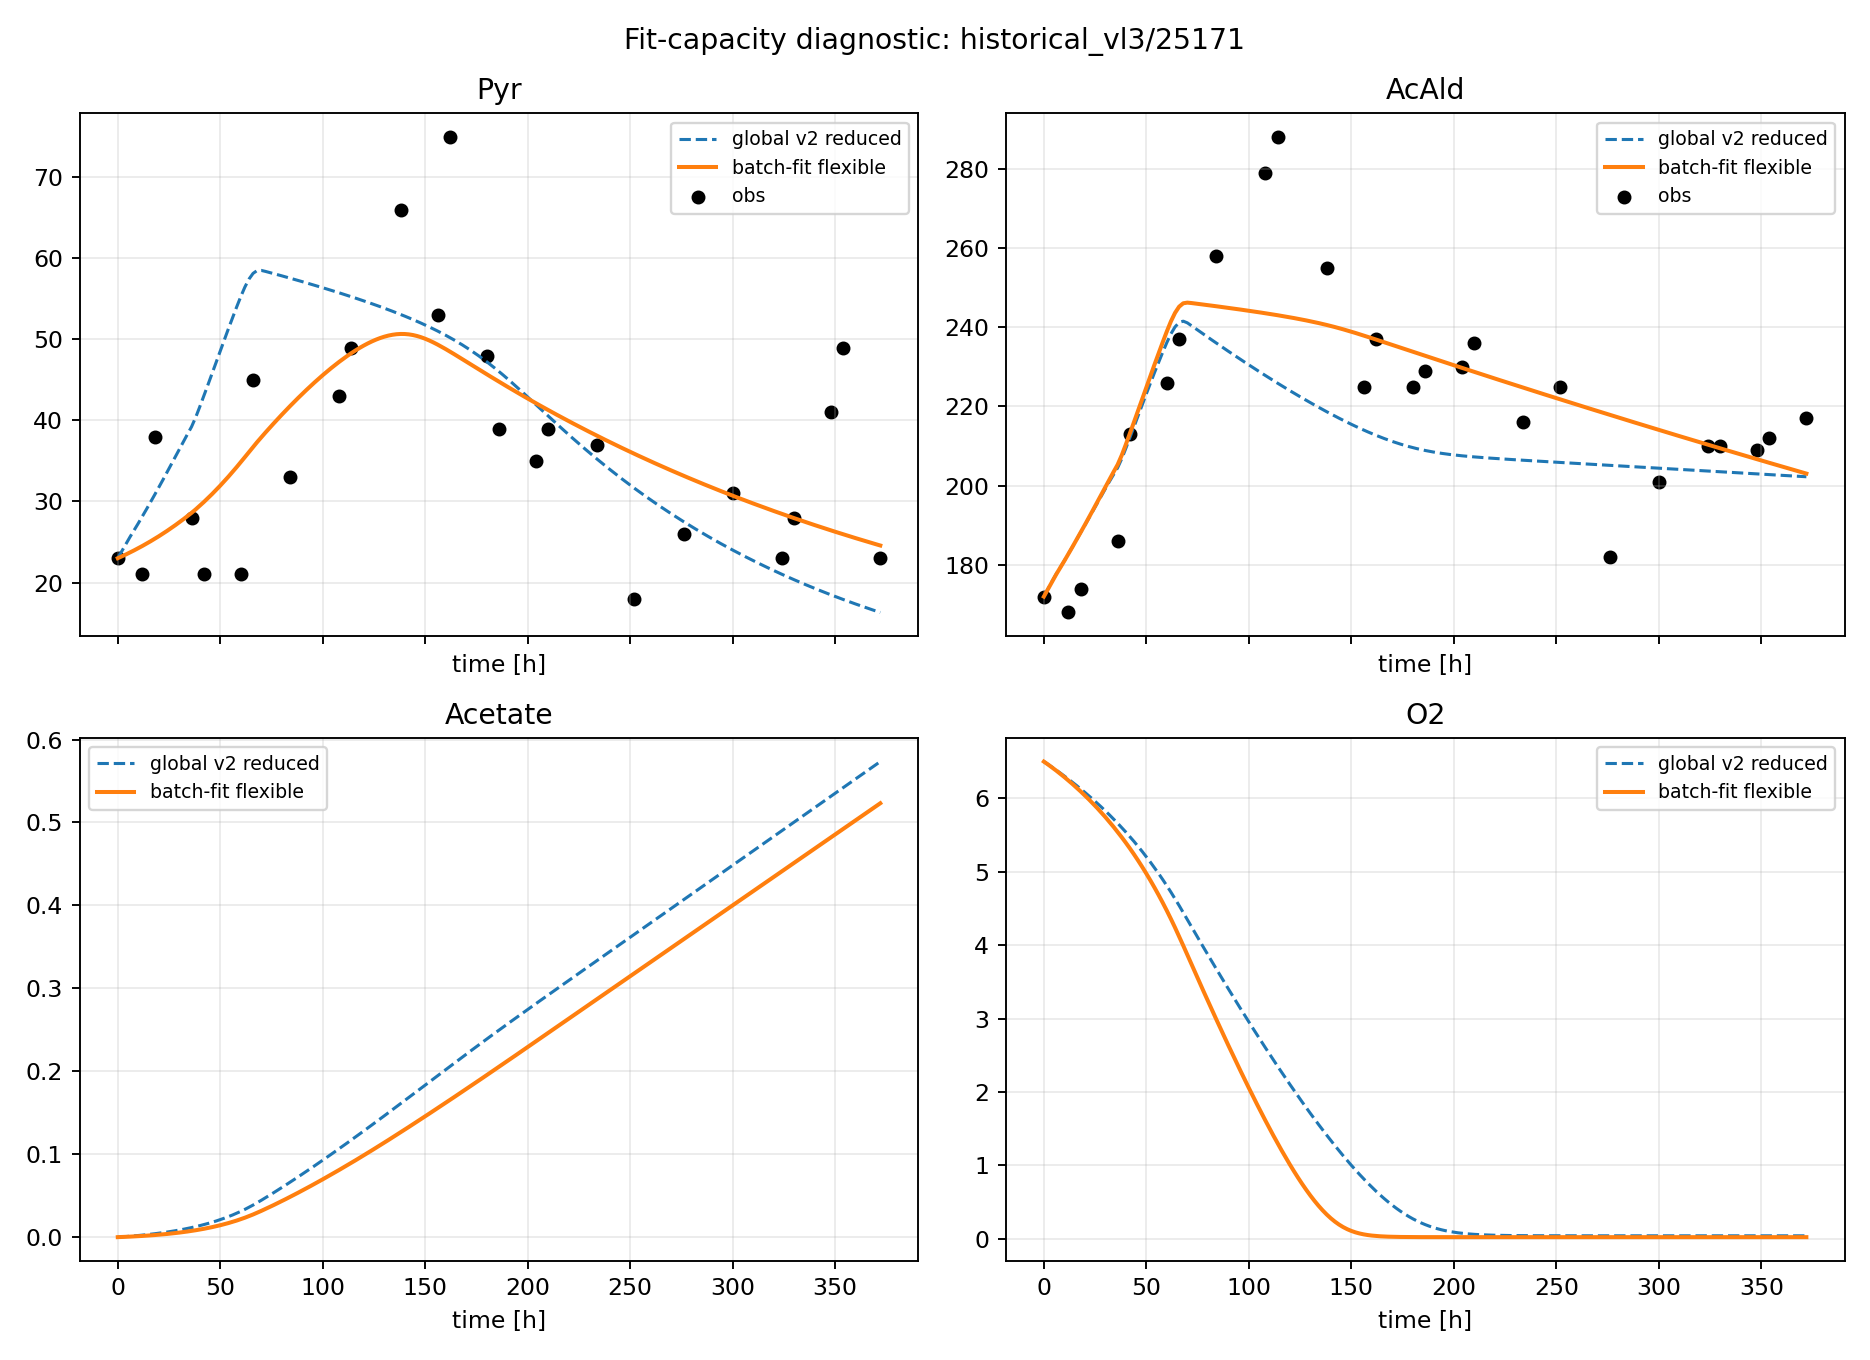

secondary_fit_capacity_natural_LAB004.png


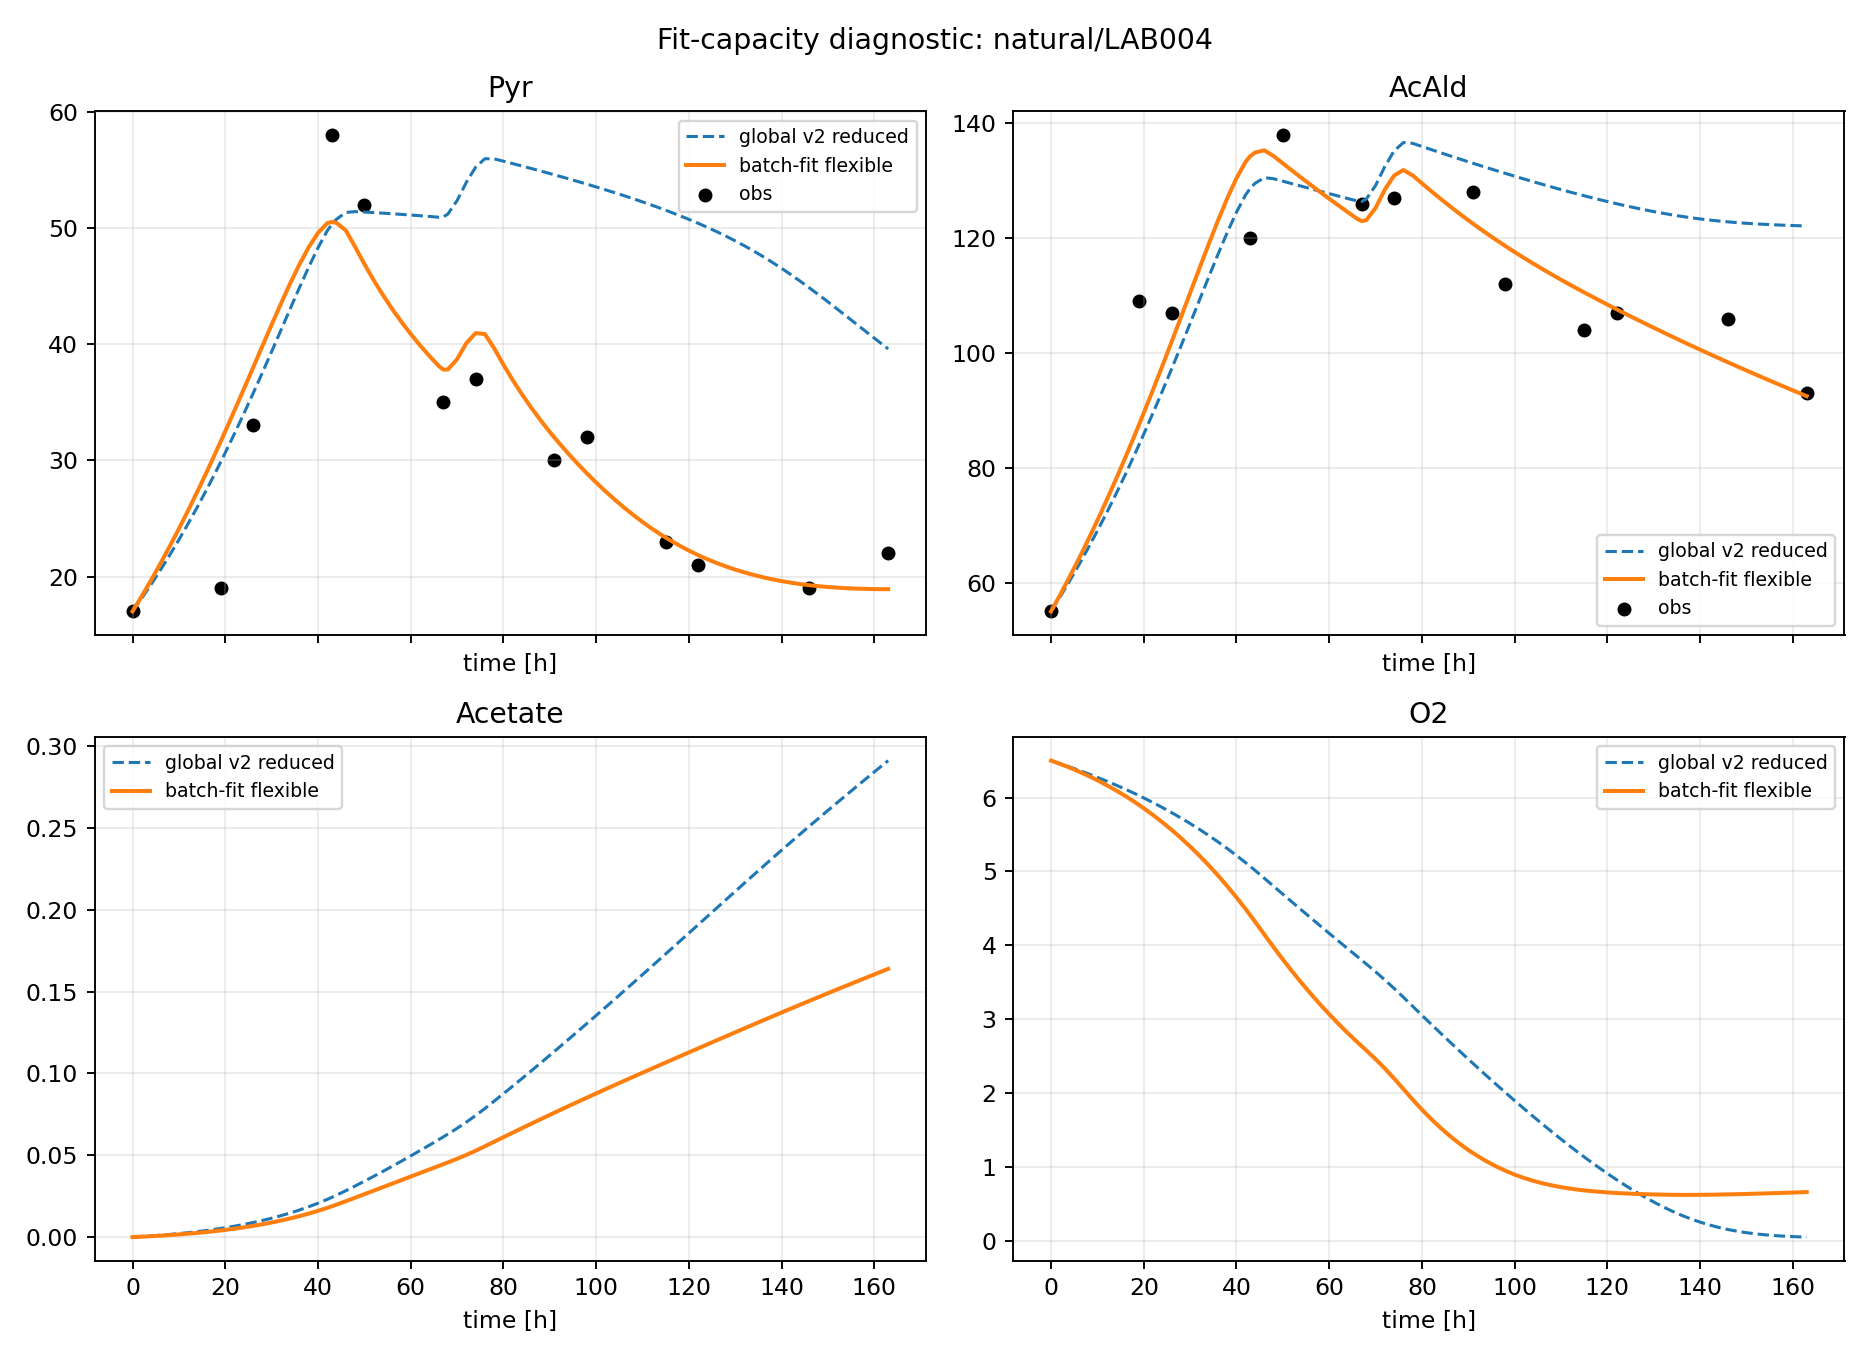

secondary_fit_capacity_natural_LAB005.png


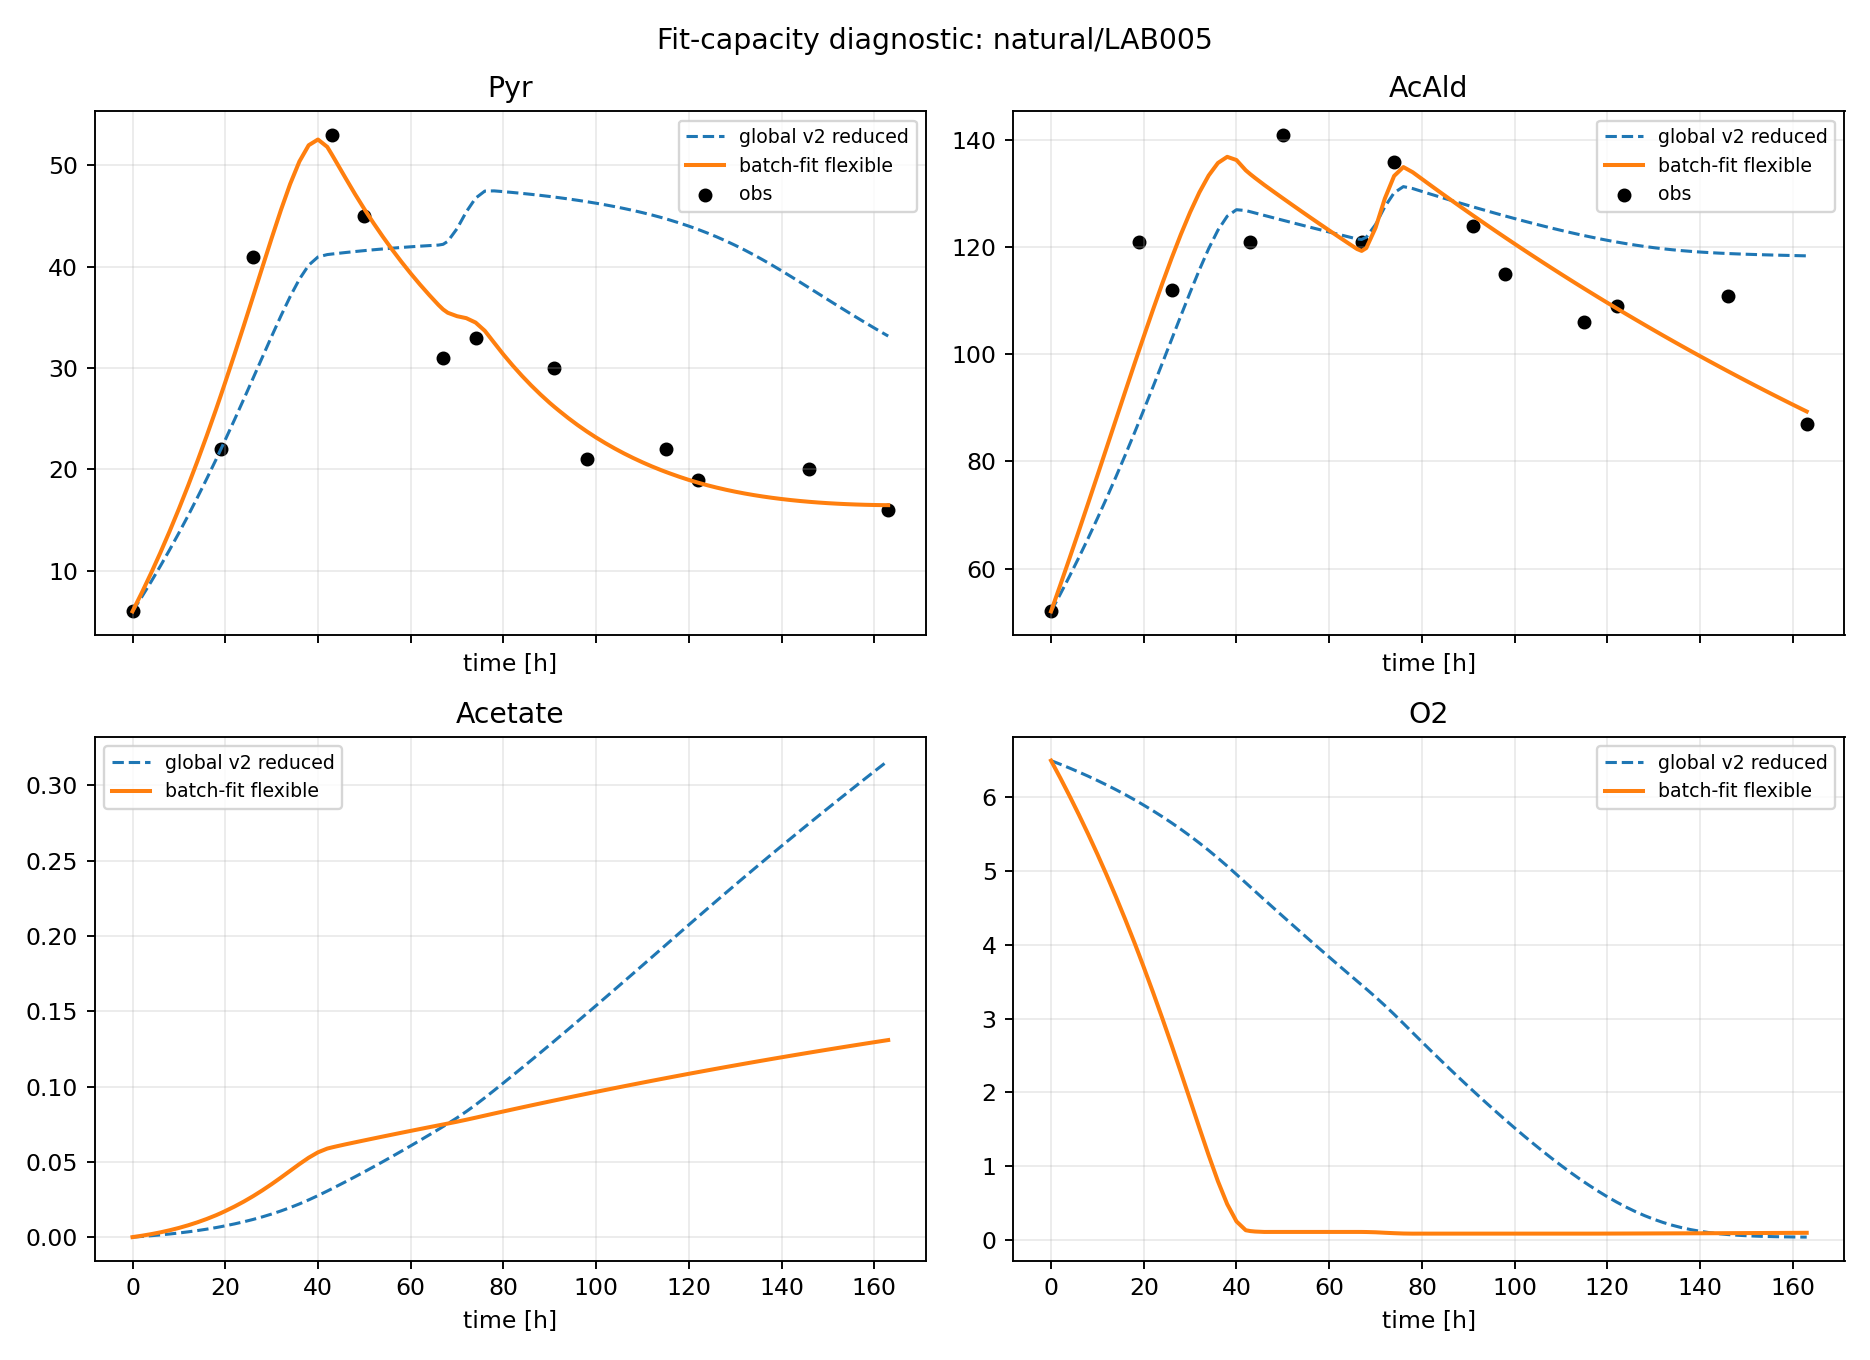

secondary_fit_capacity_natural_LAB006.png


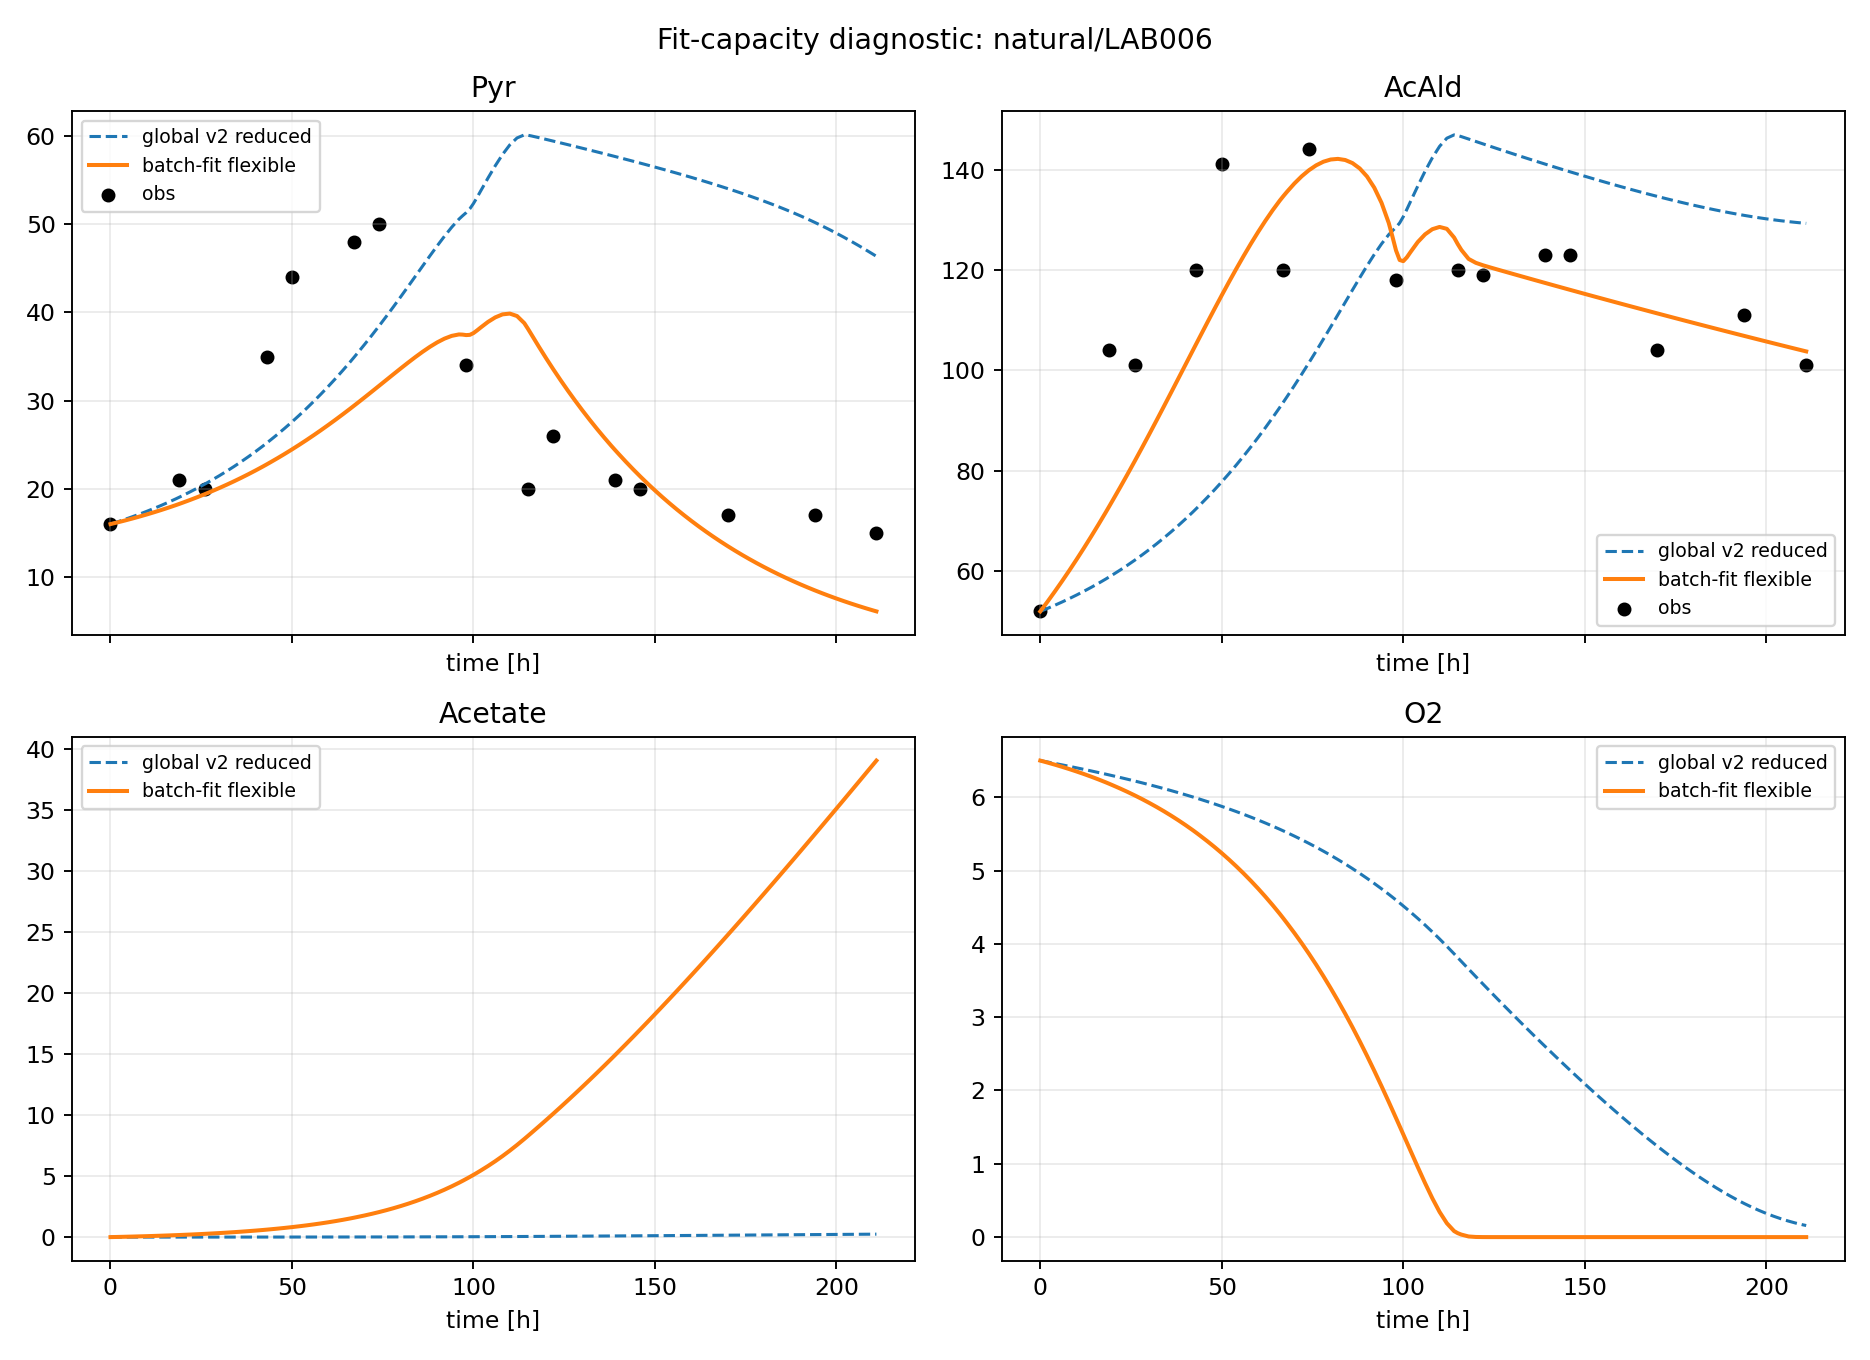

secondary_fit_capacity_natural_LAB007.png


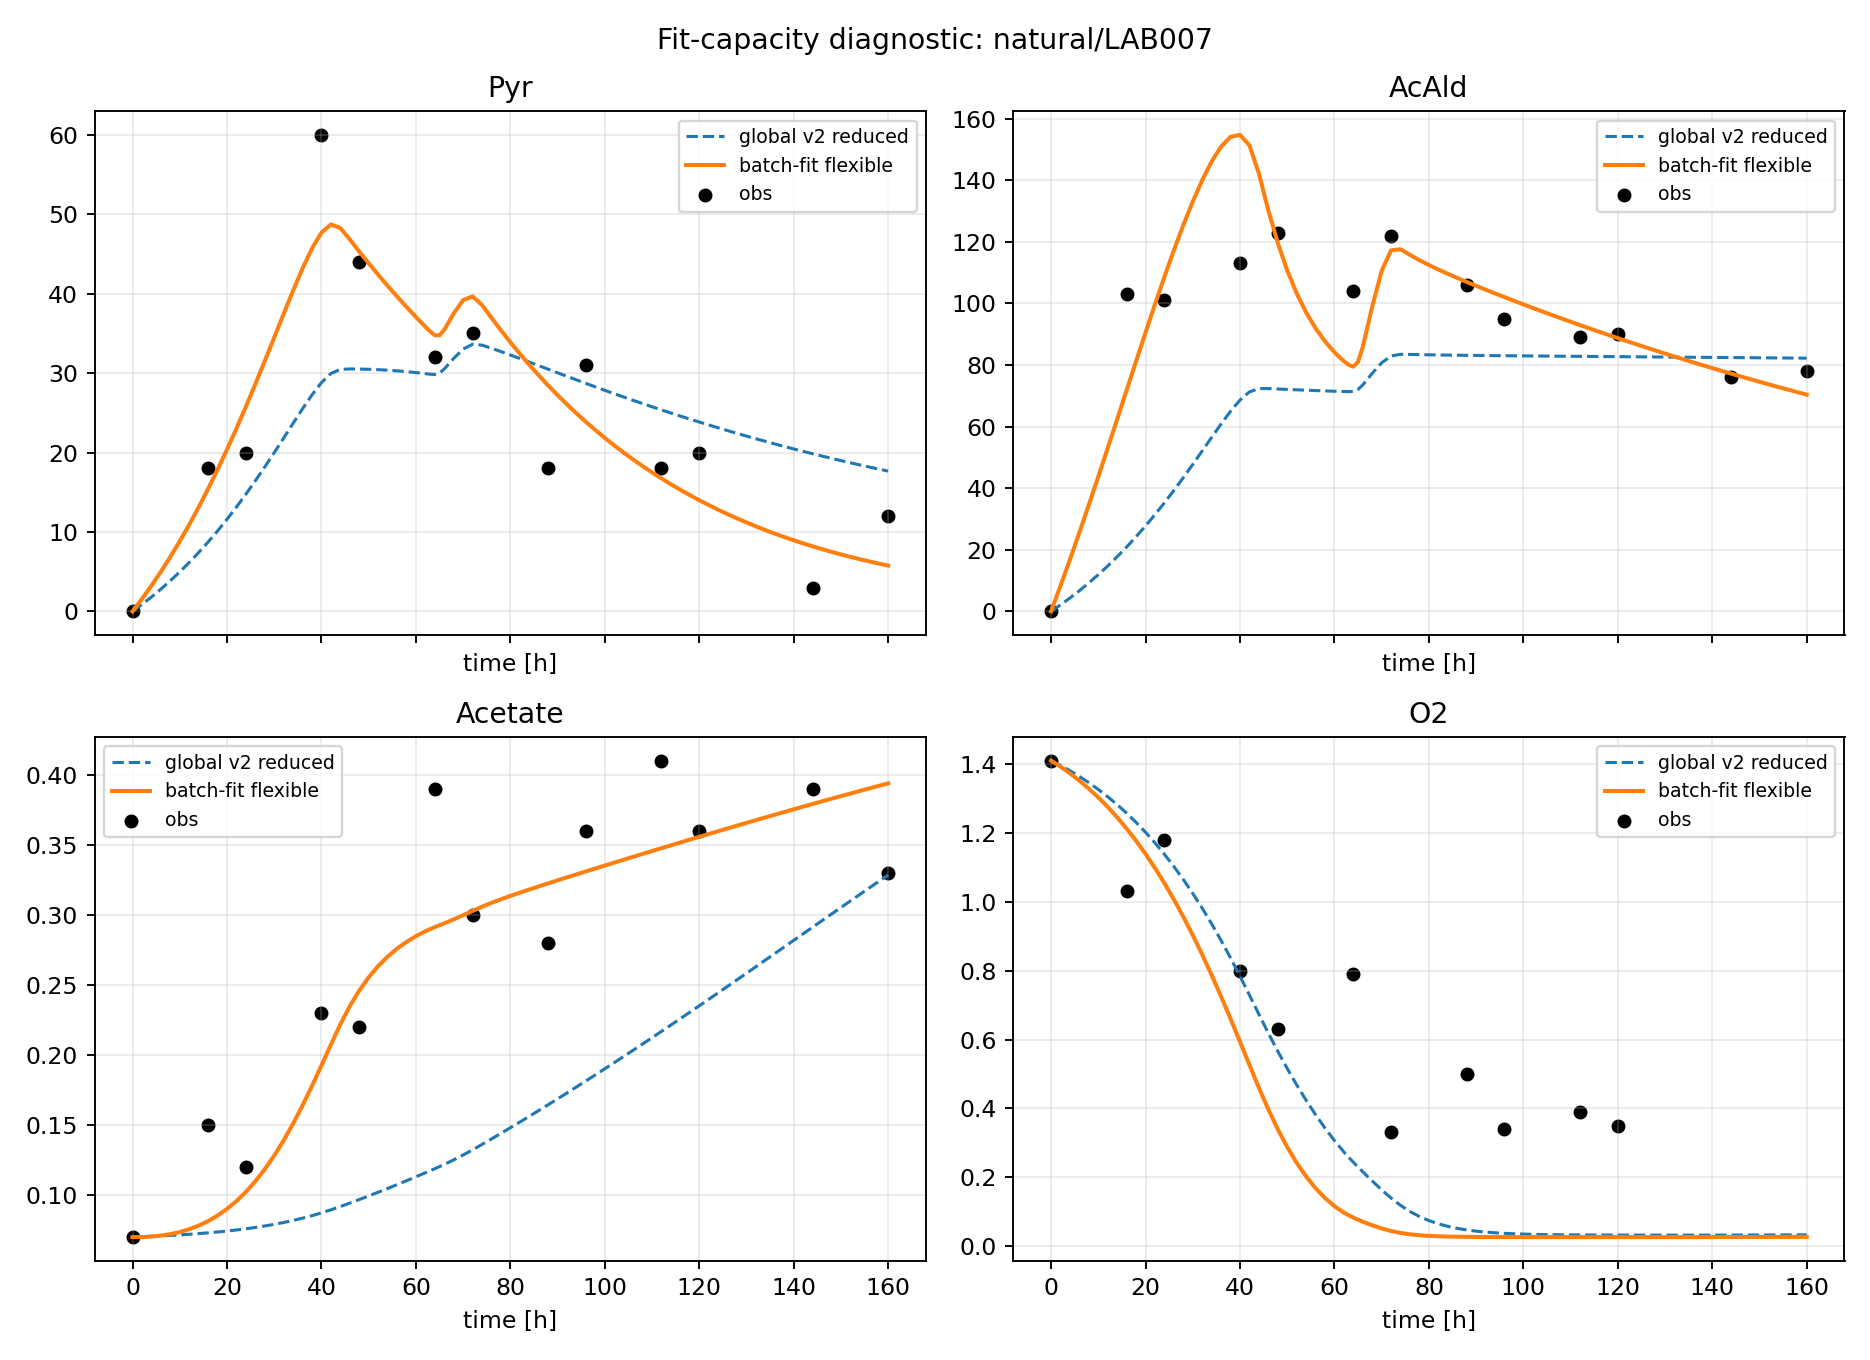

secondary_fit_capacity_natural_LAB008.png


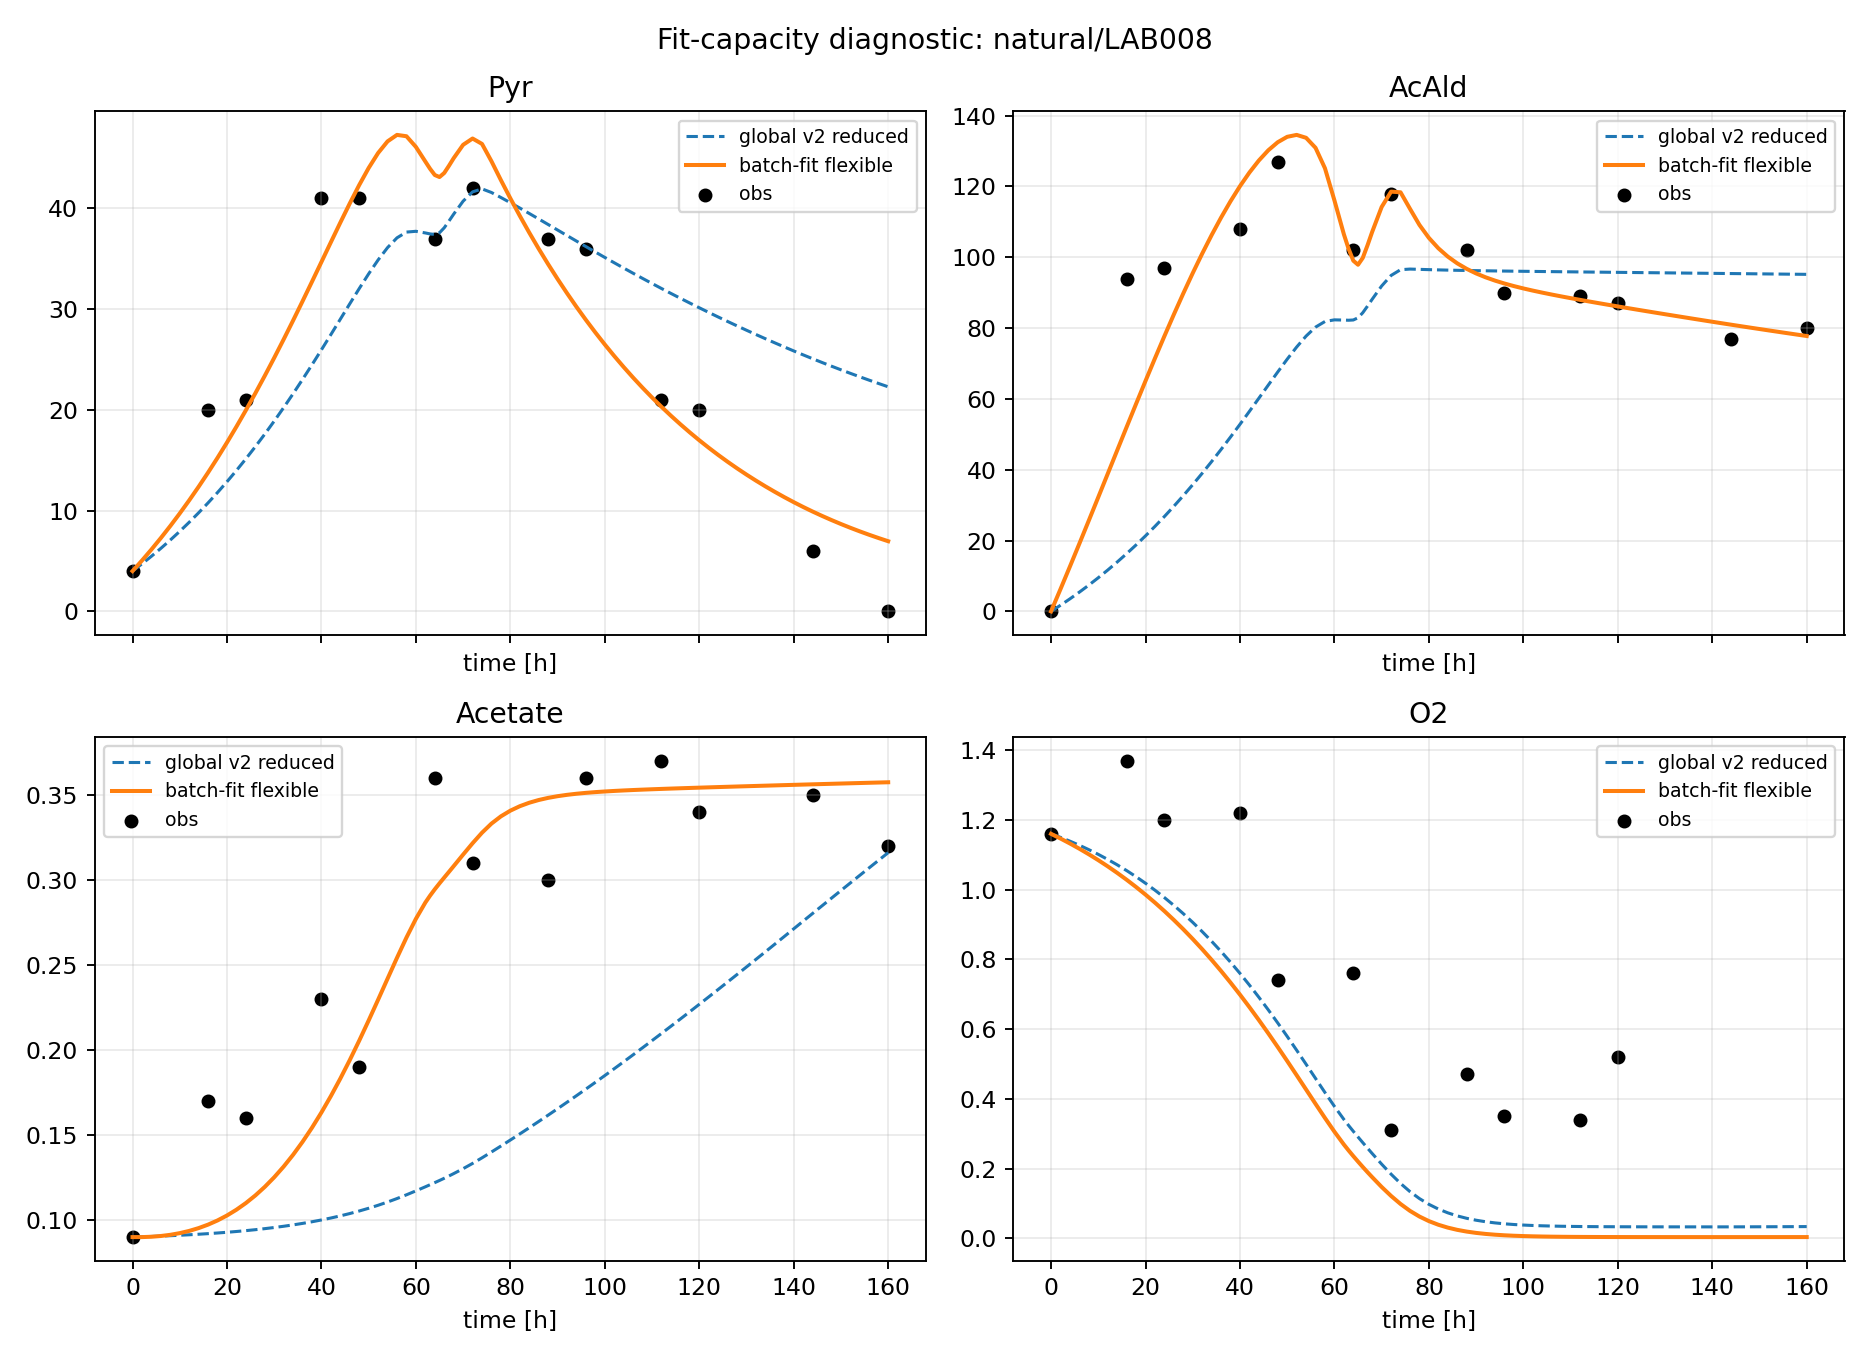

secondary_fit_capacity_natural_LAB009.png


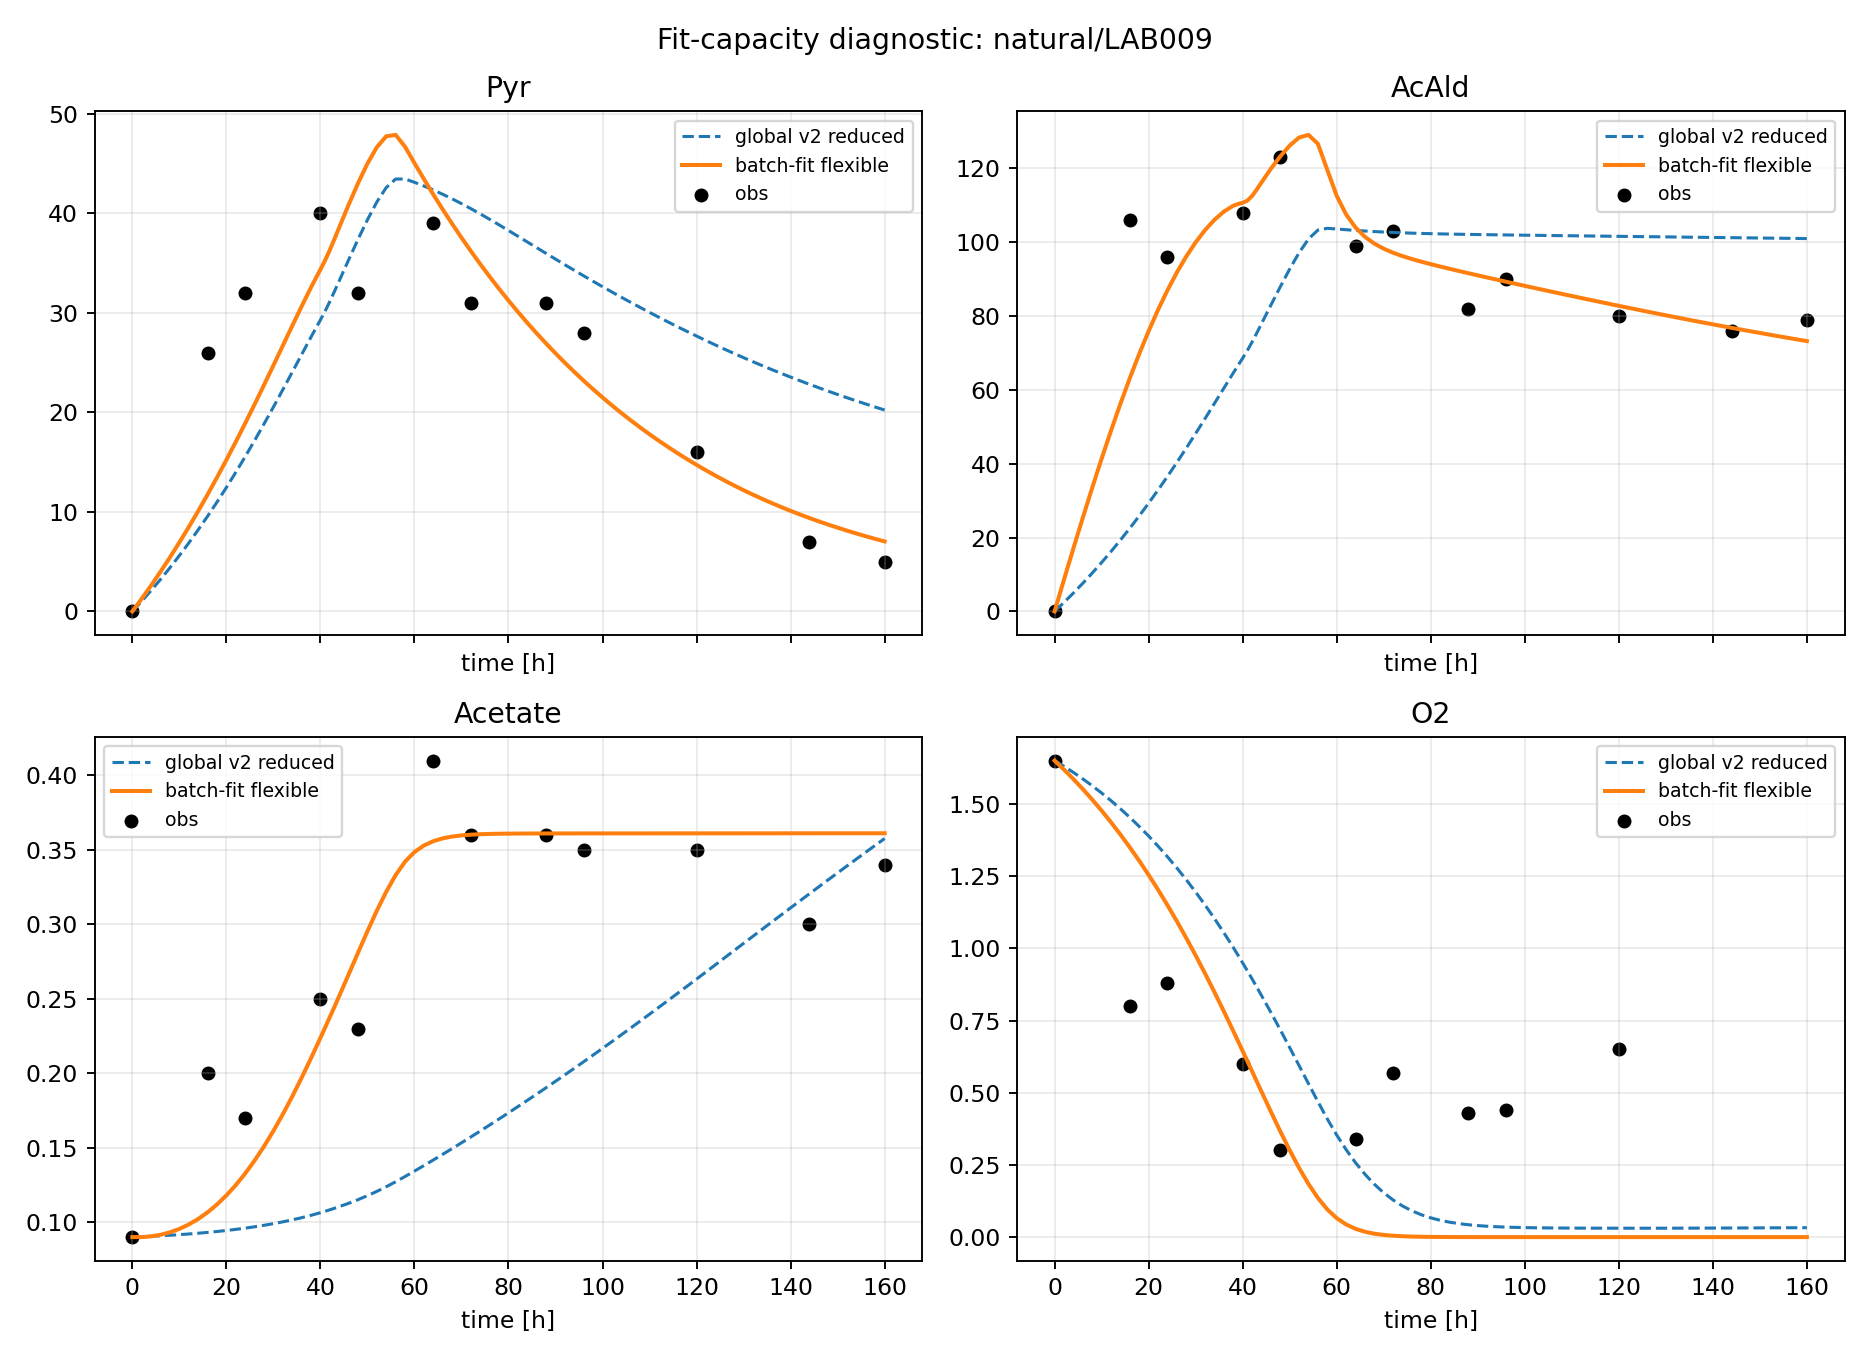

secondary_fit_capacity_natural_LAB010.png


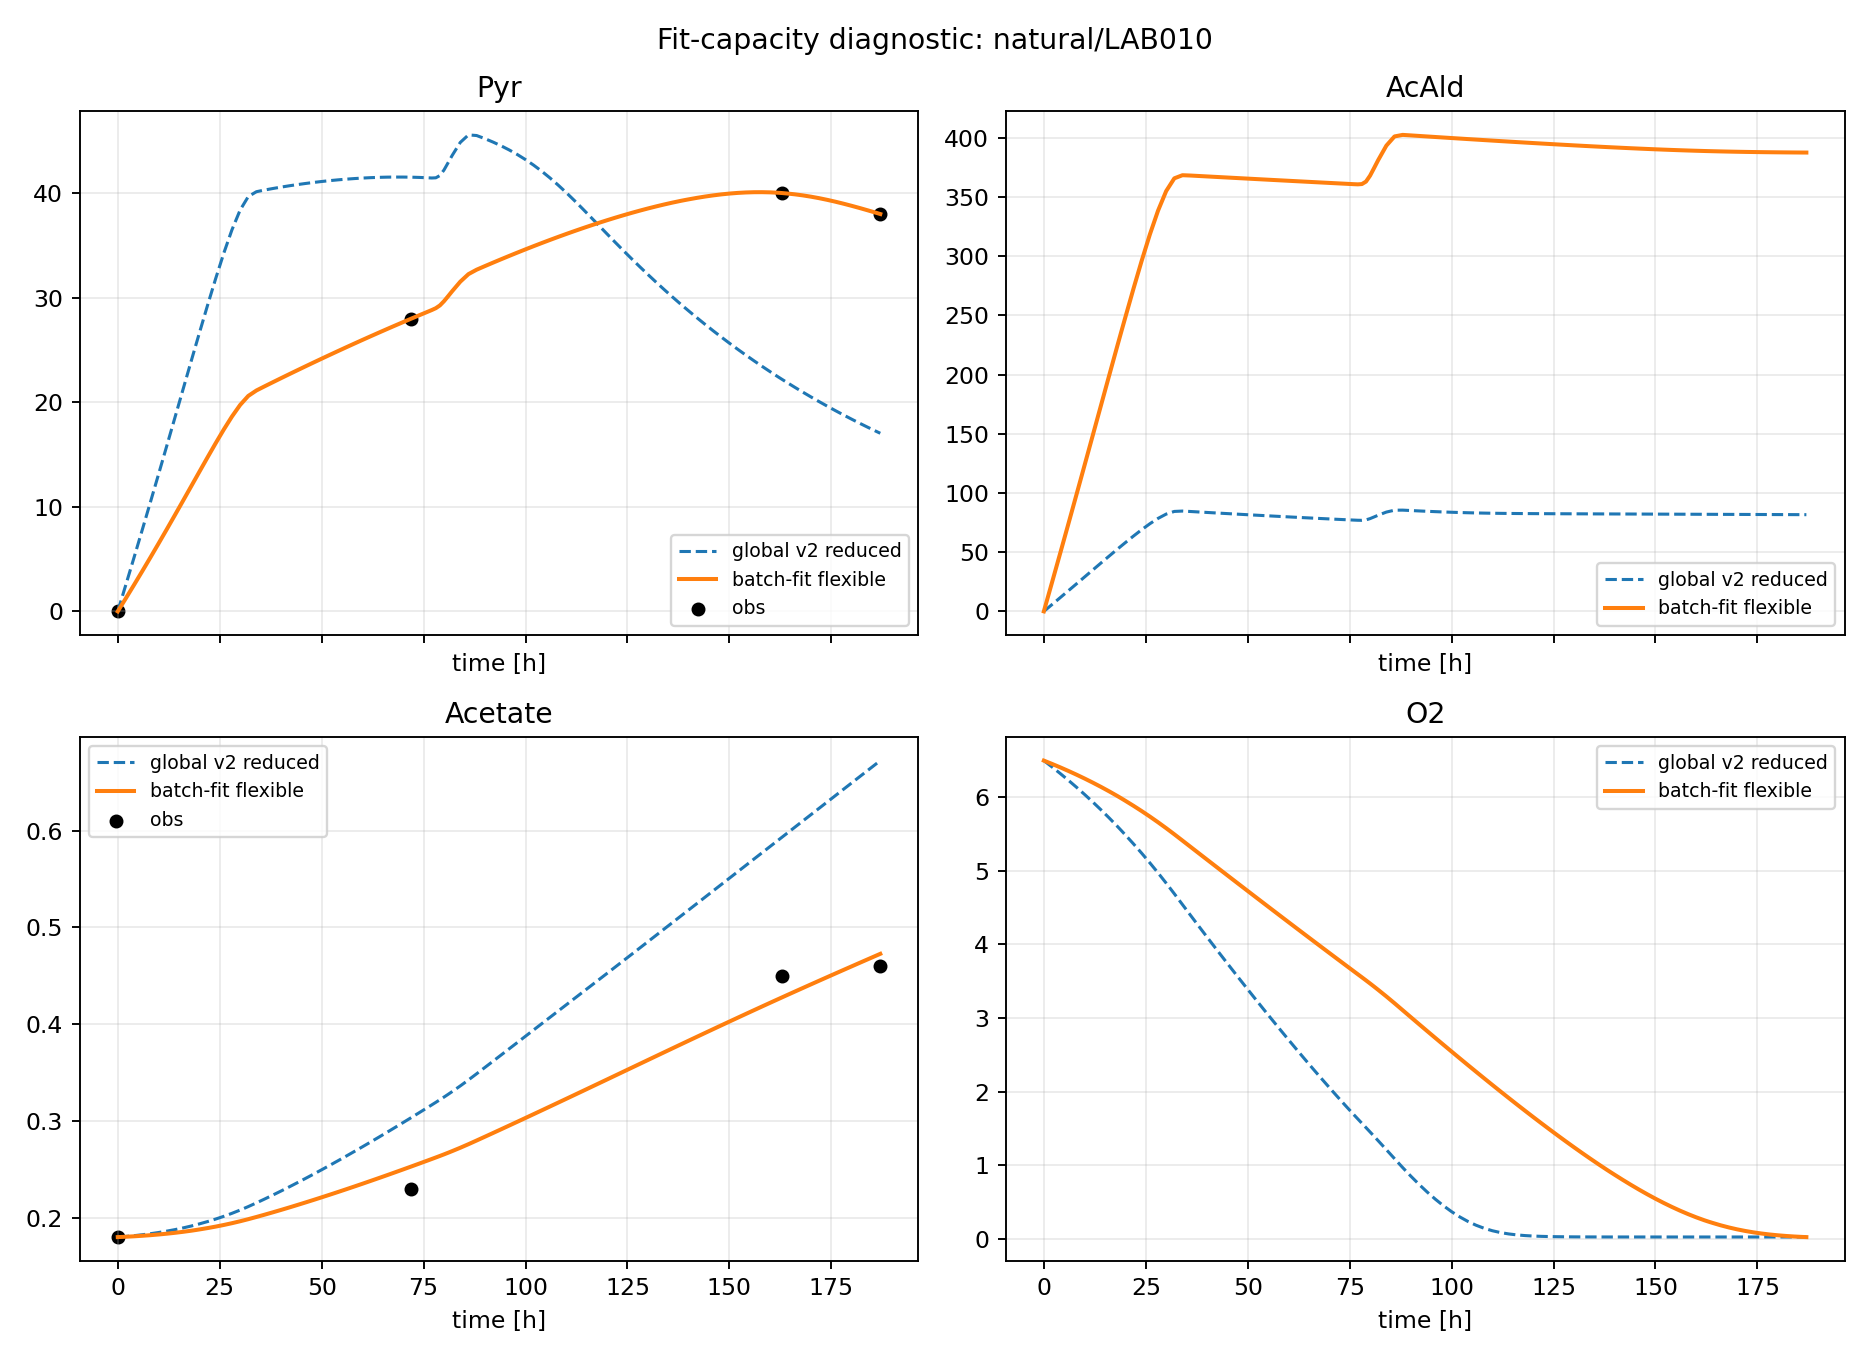

secondary_fit_capacity_natural_LAB011.png


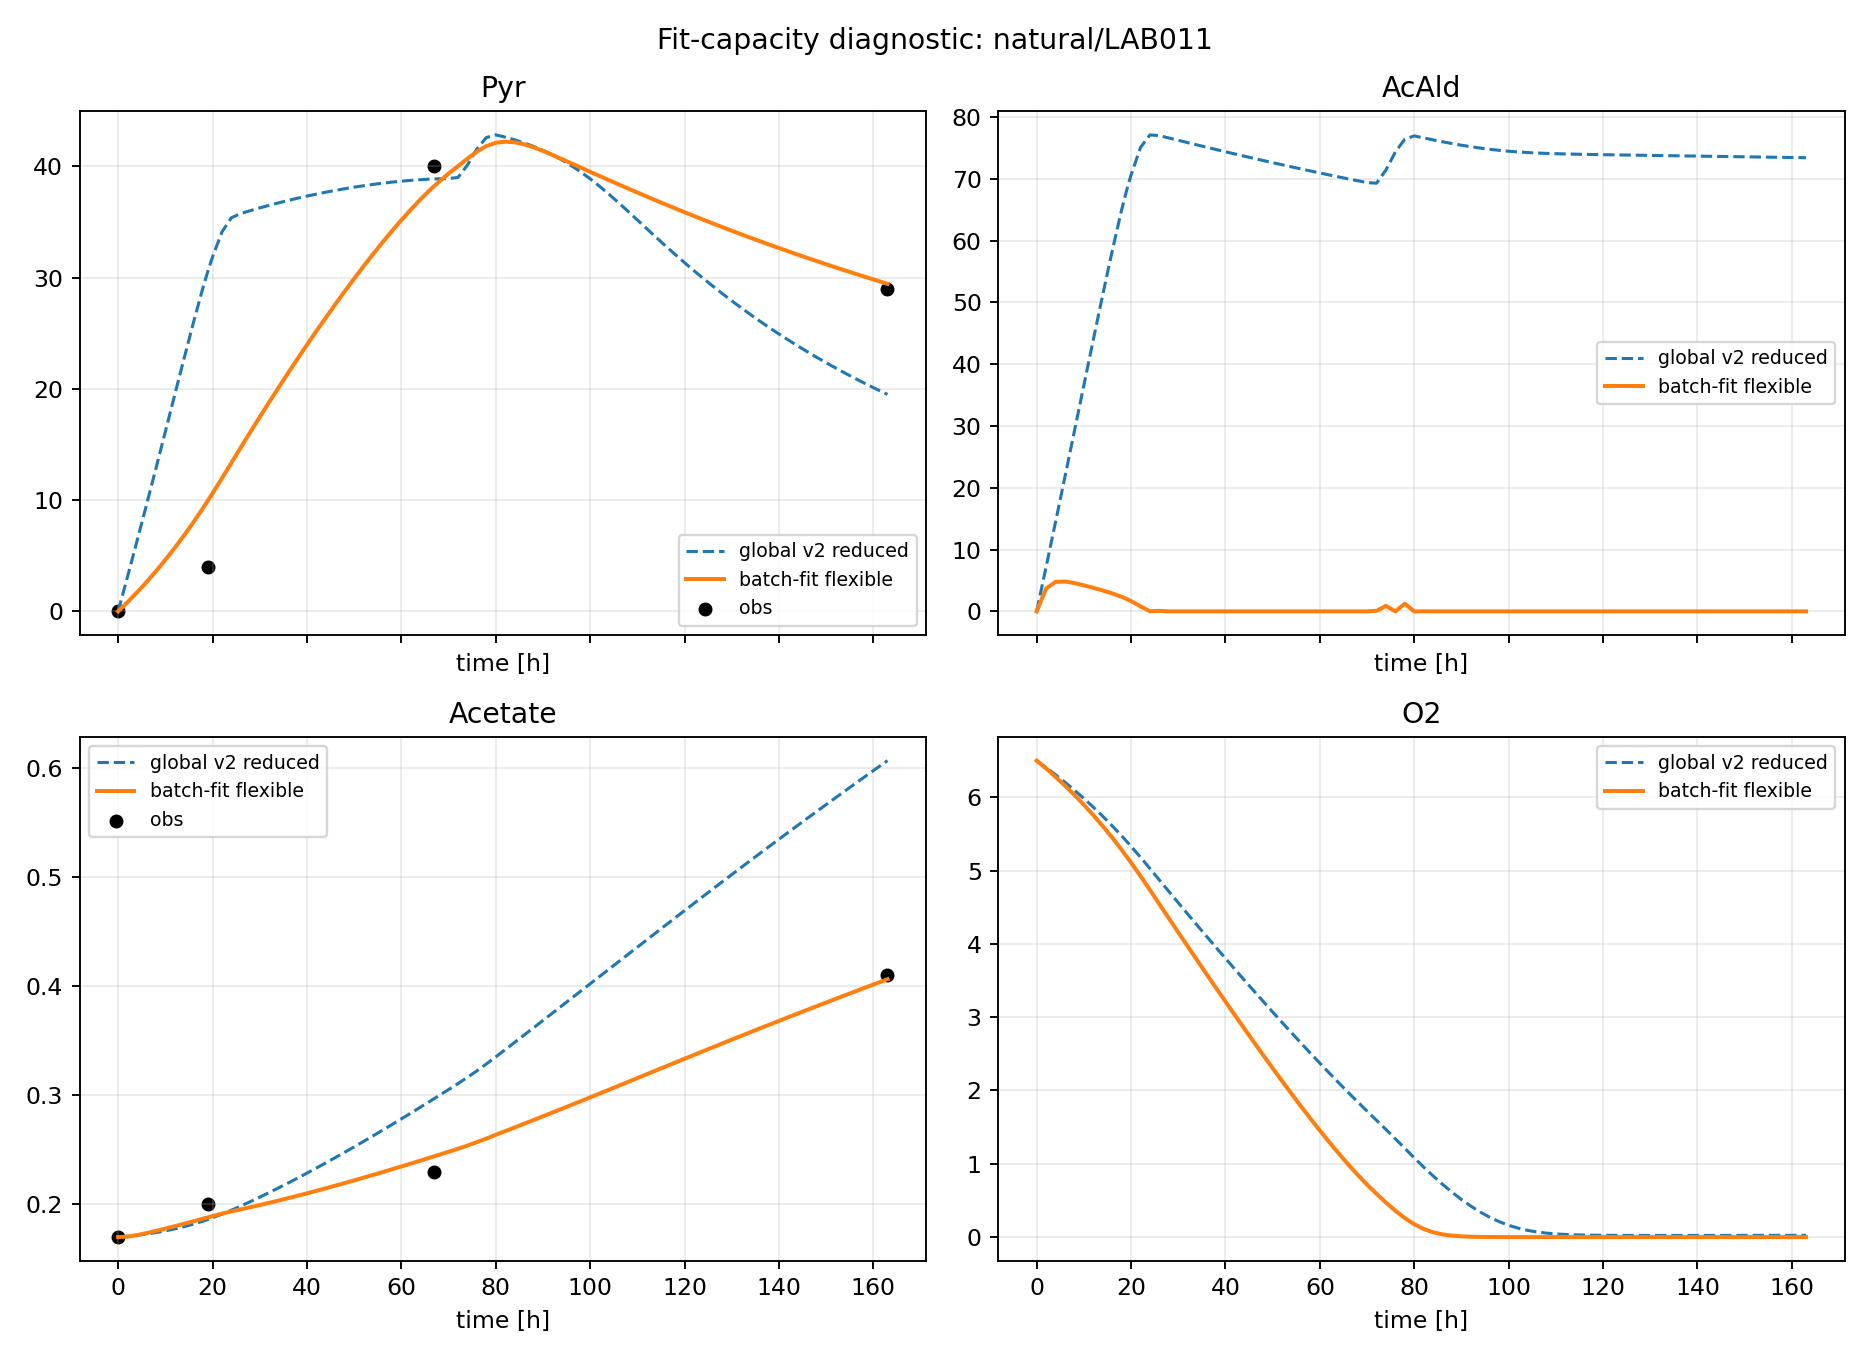

secondary_fit_capacity_natural_LAB012.png


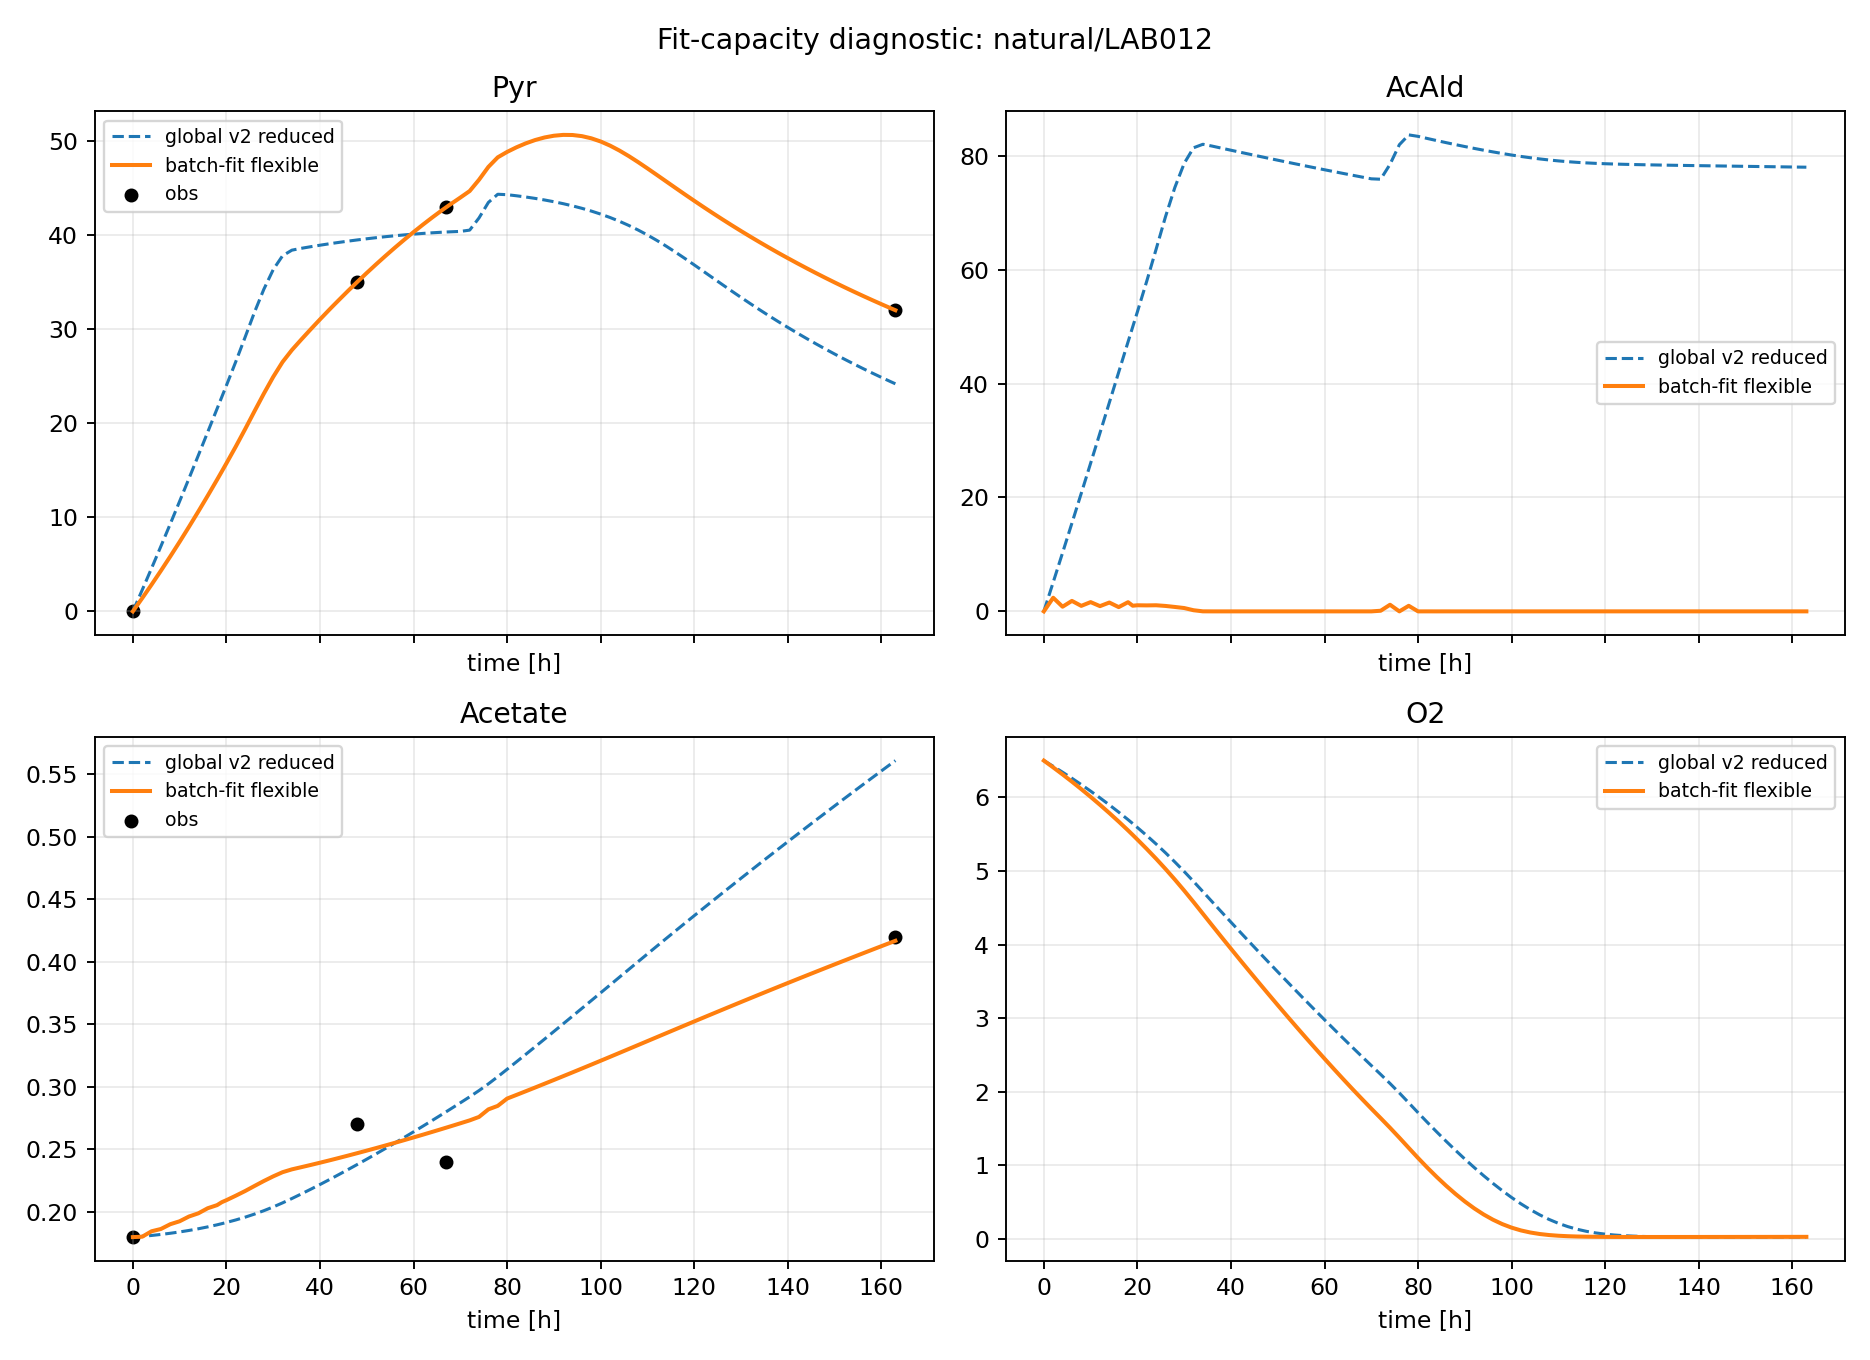

secondary_fit_capacity_synthetic_MS007.png


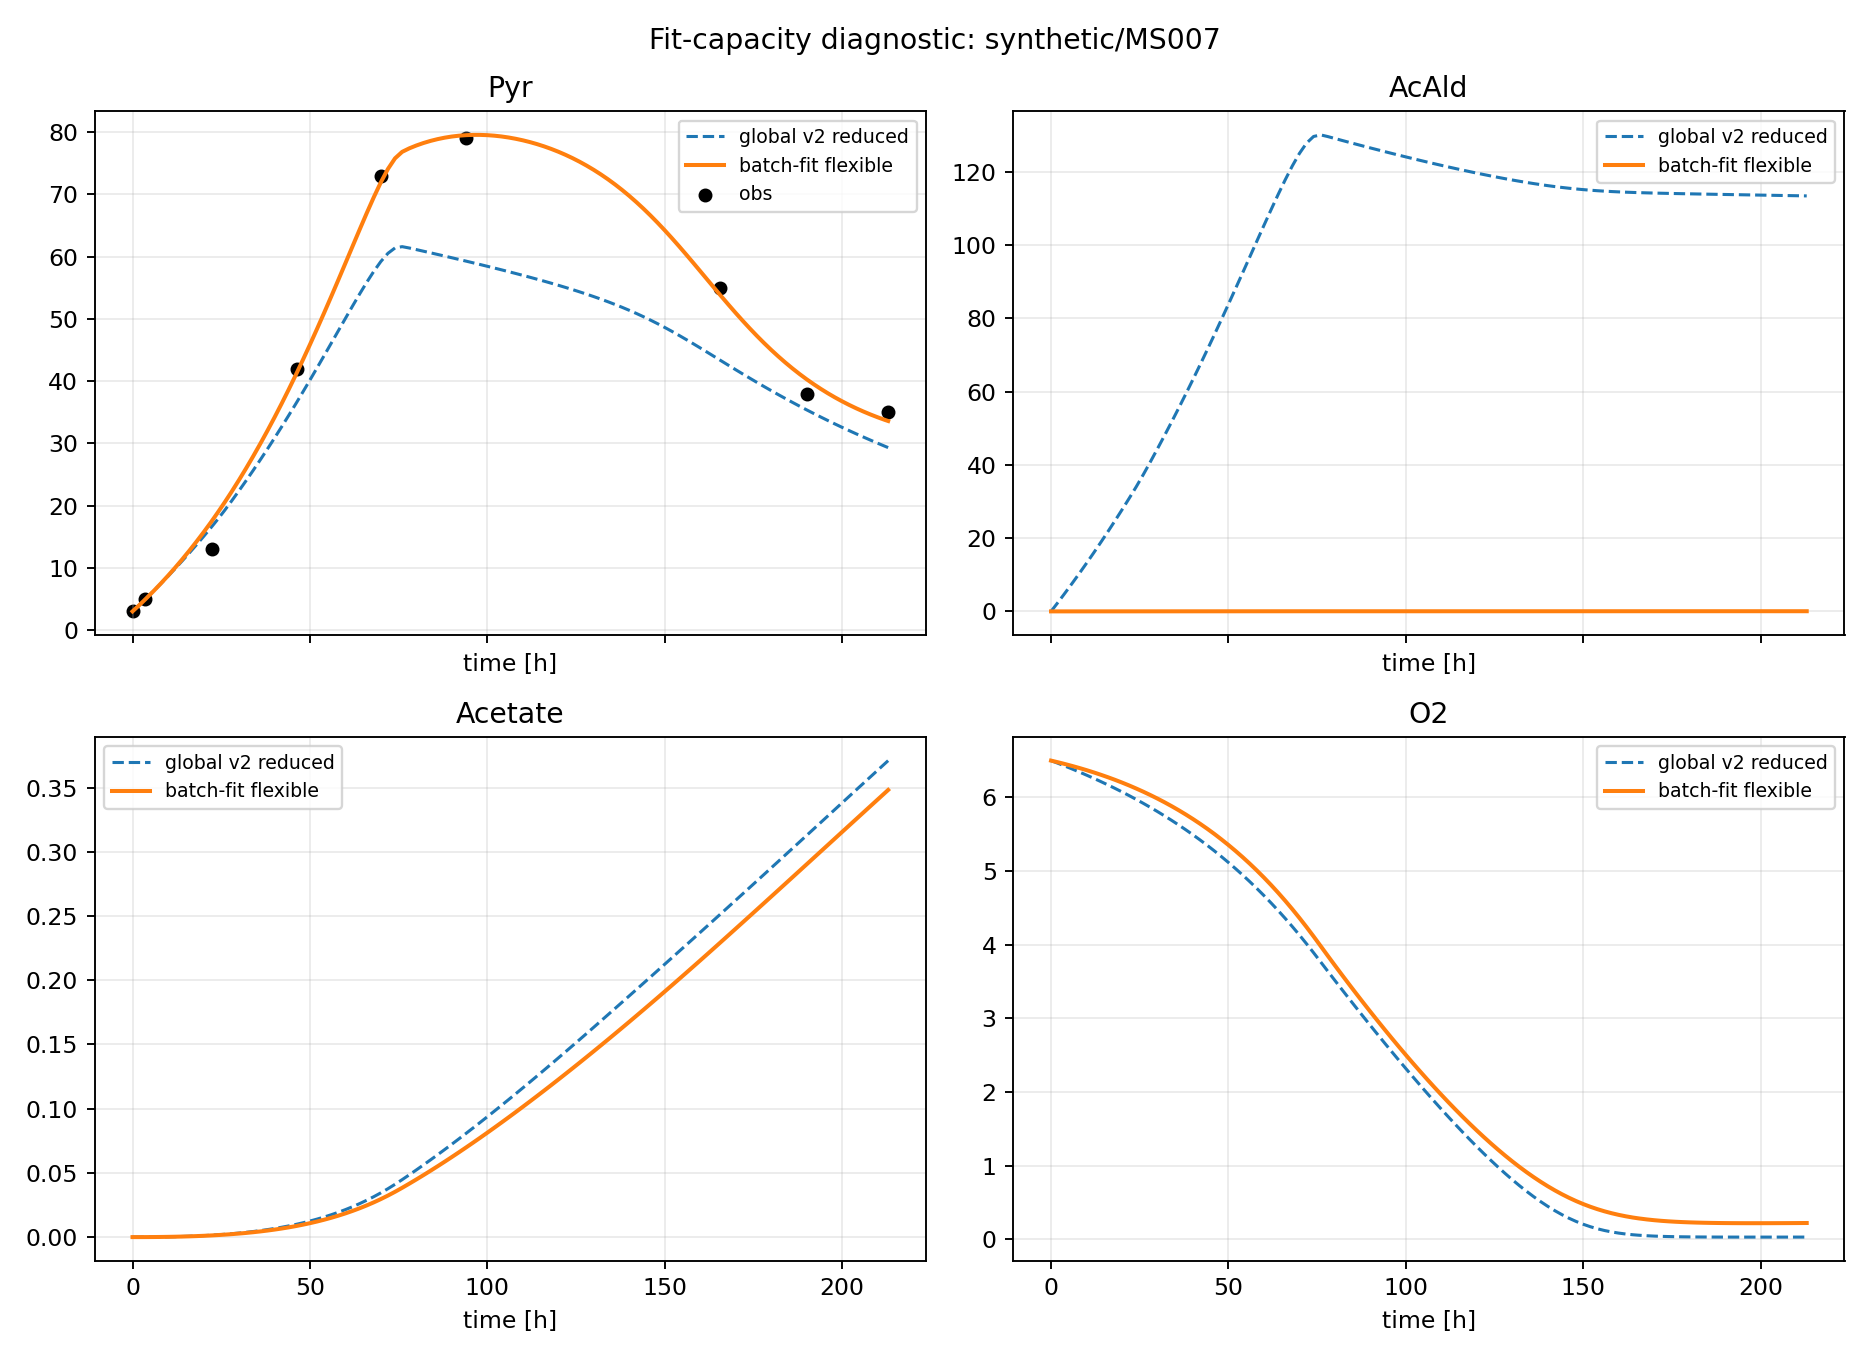

secondary_fit_capacity_synthetic_MS008.png


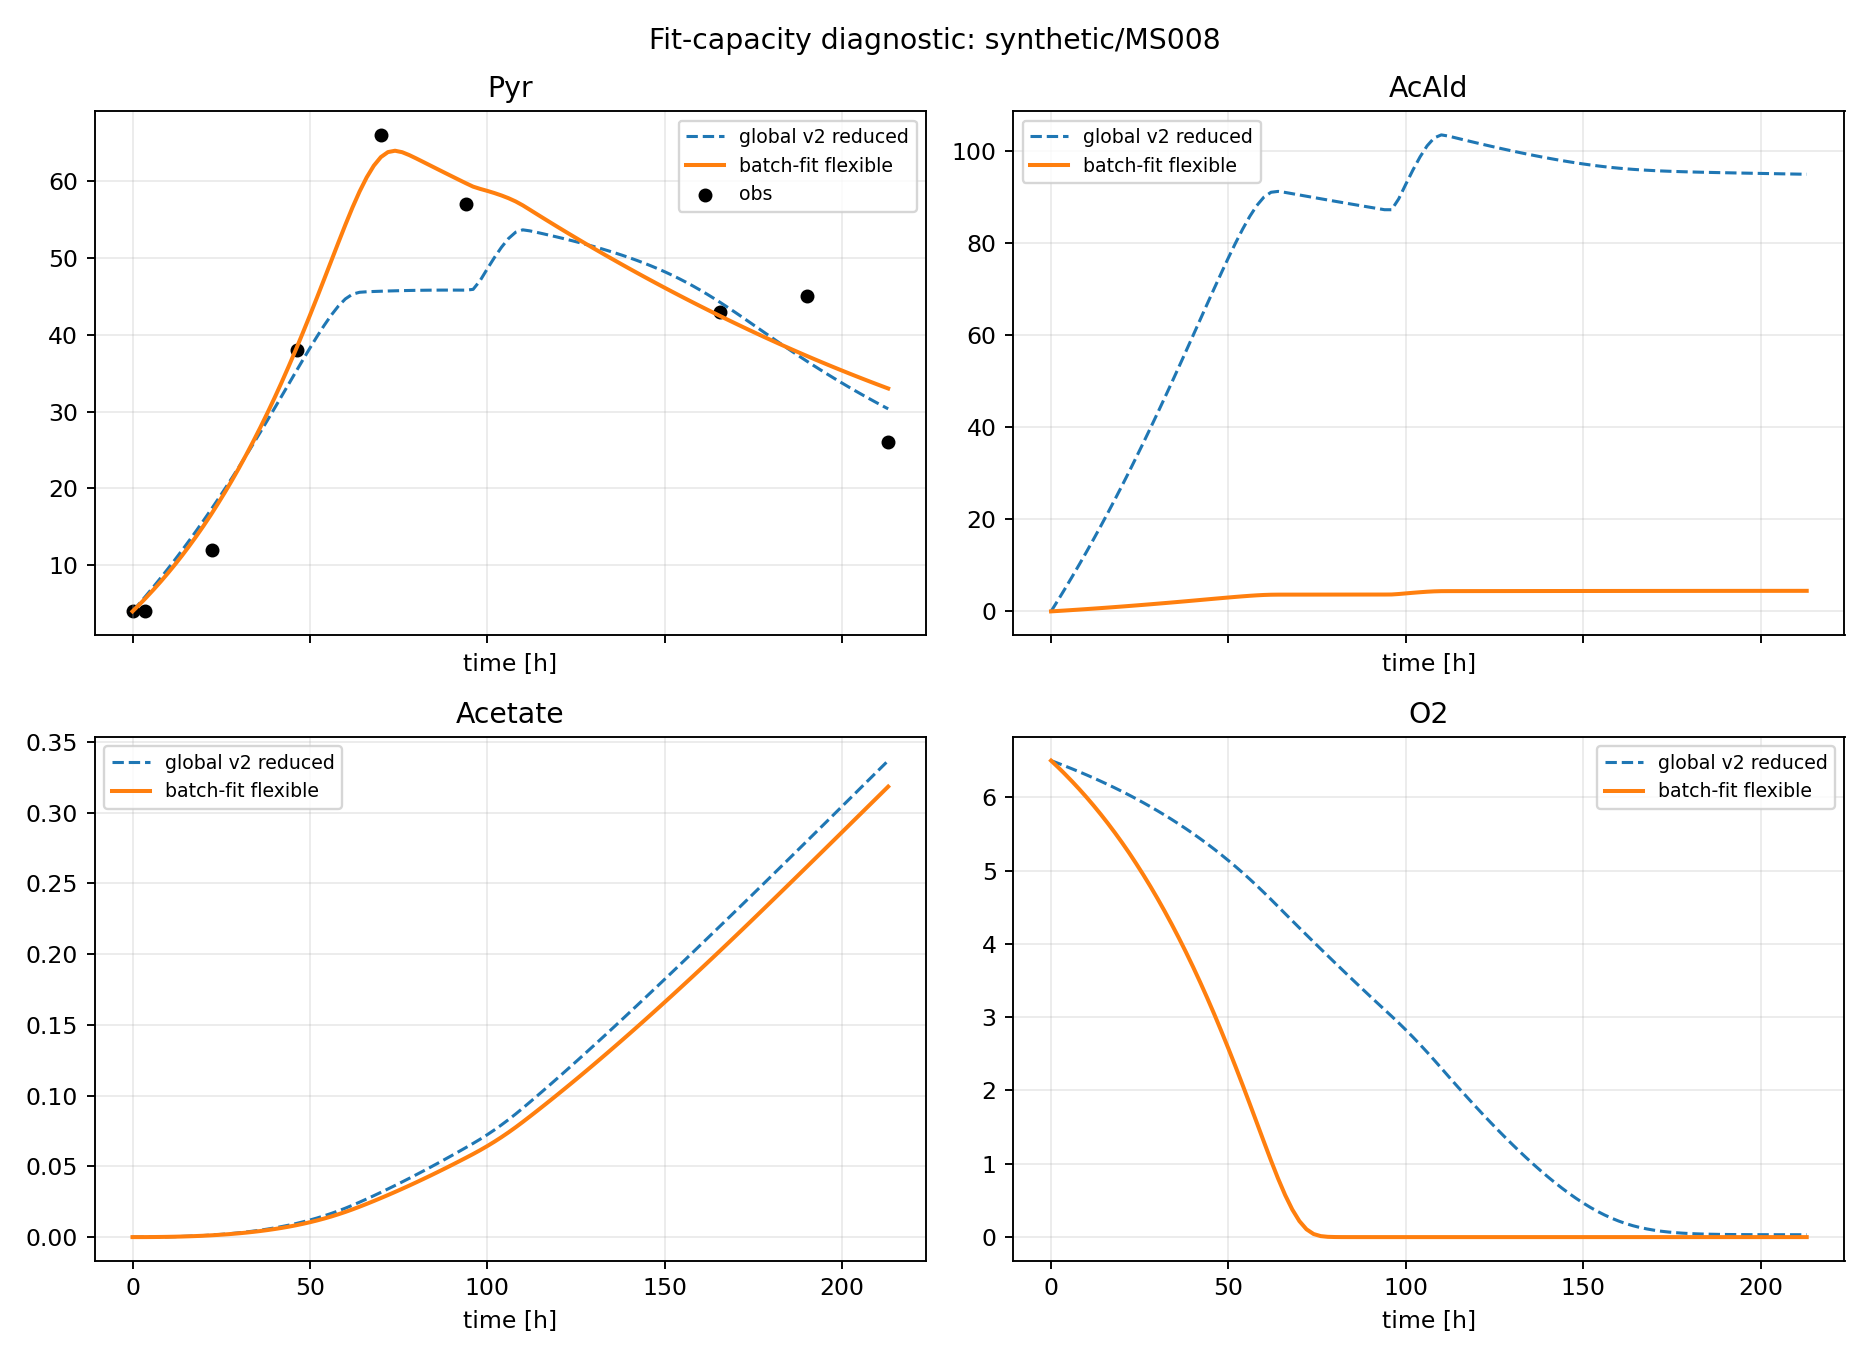

secondary_fit_capacity_synthetic_MS009.png


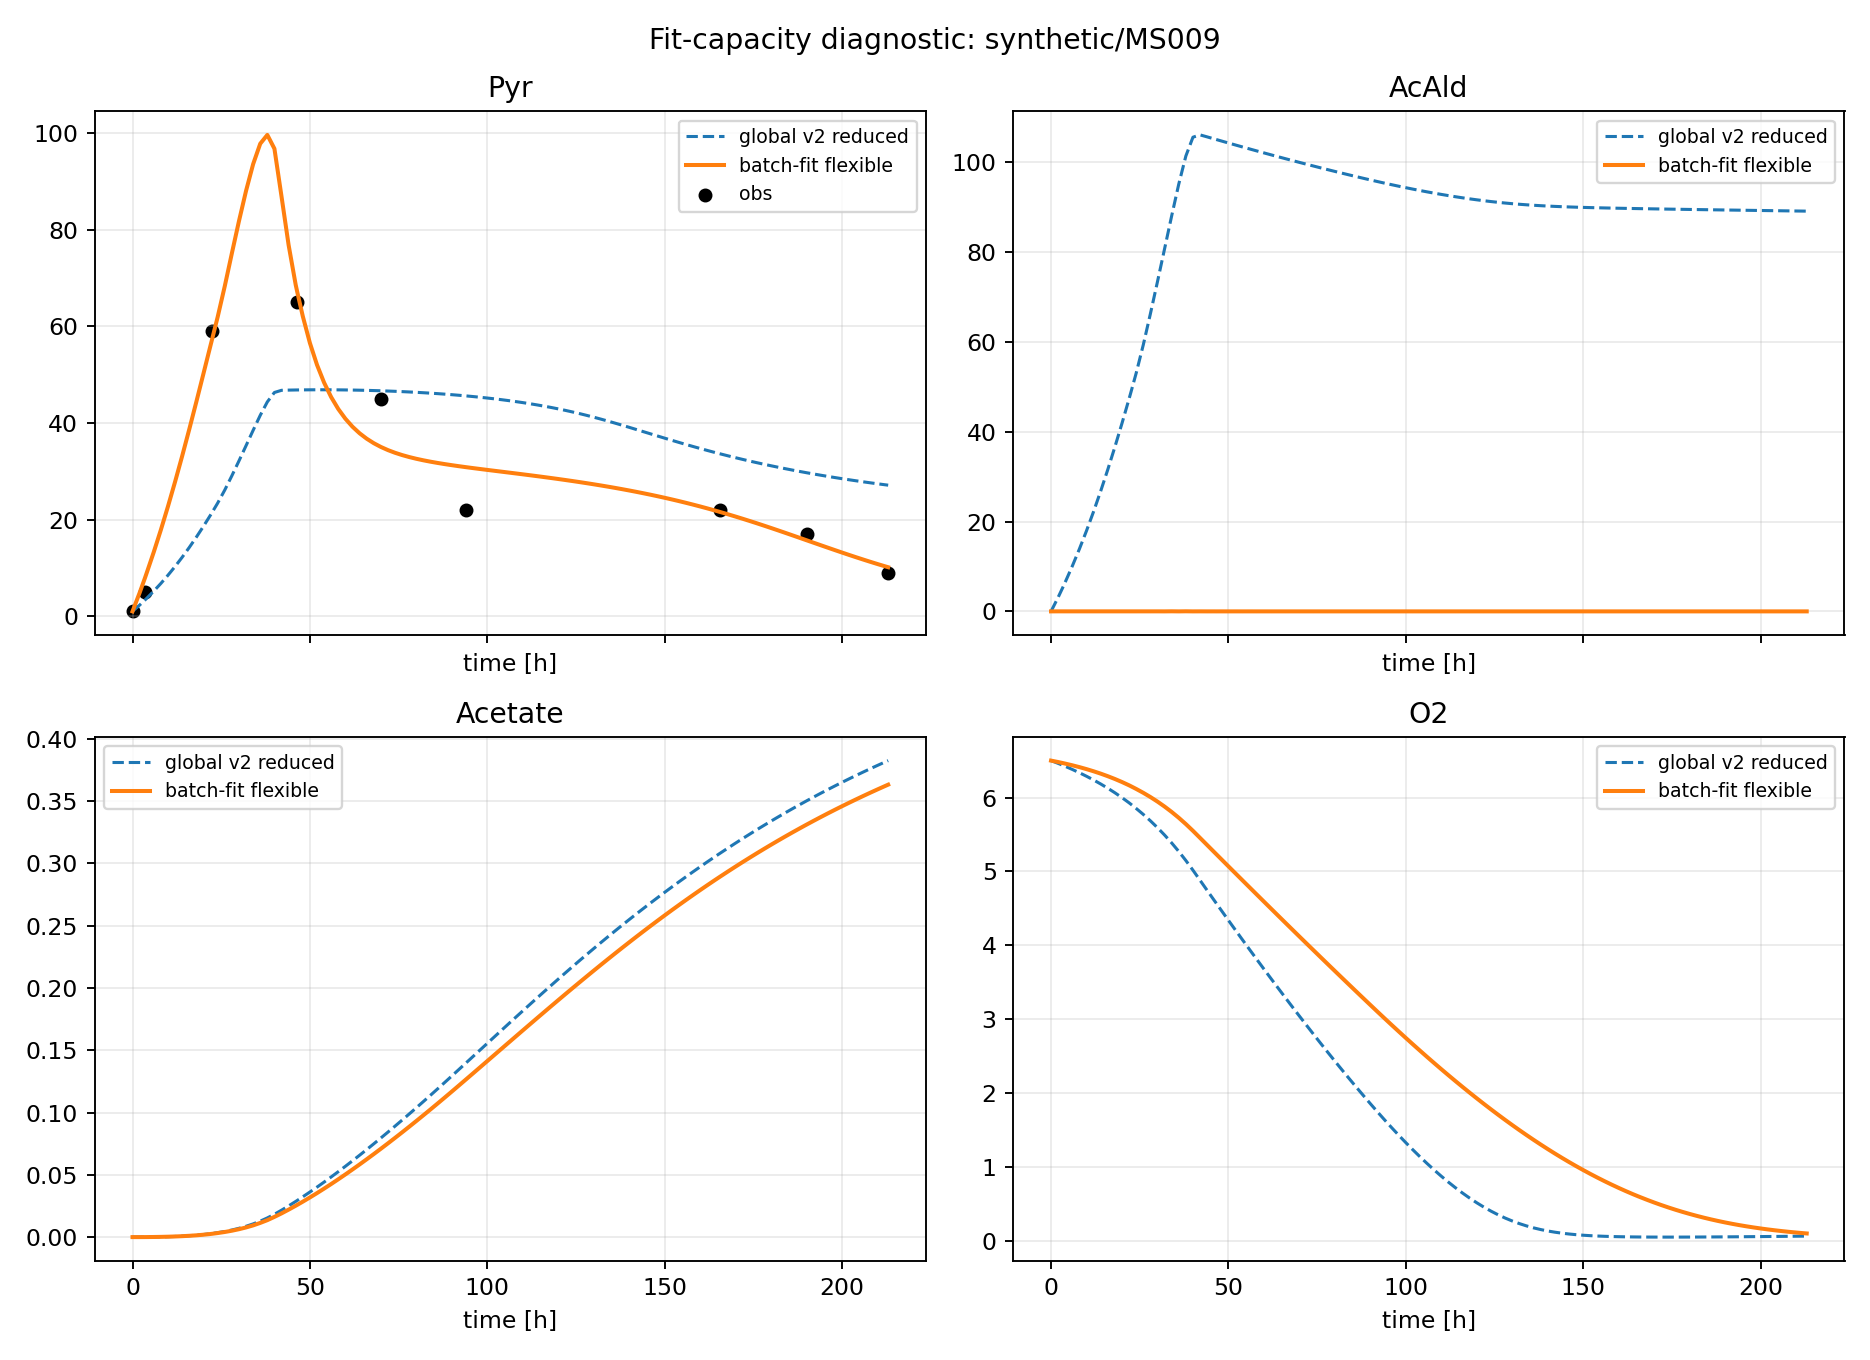

secondary_fit_capacity_synthetic_MS010.png


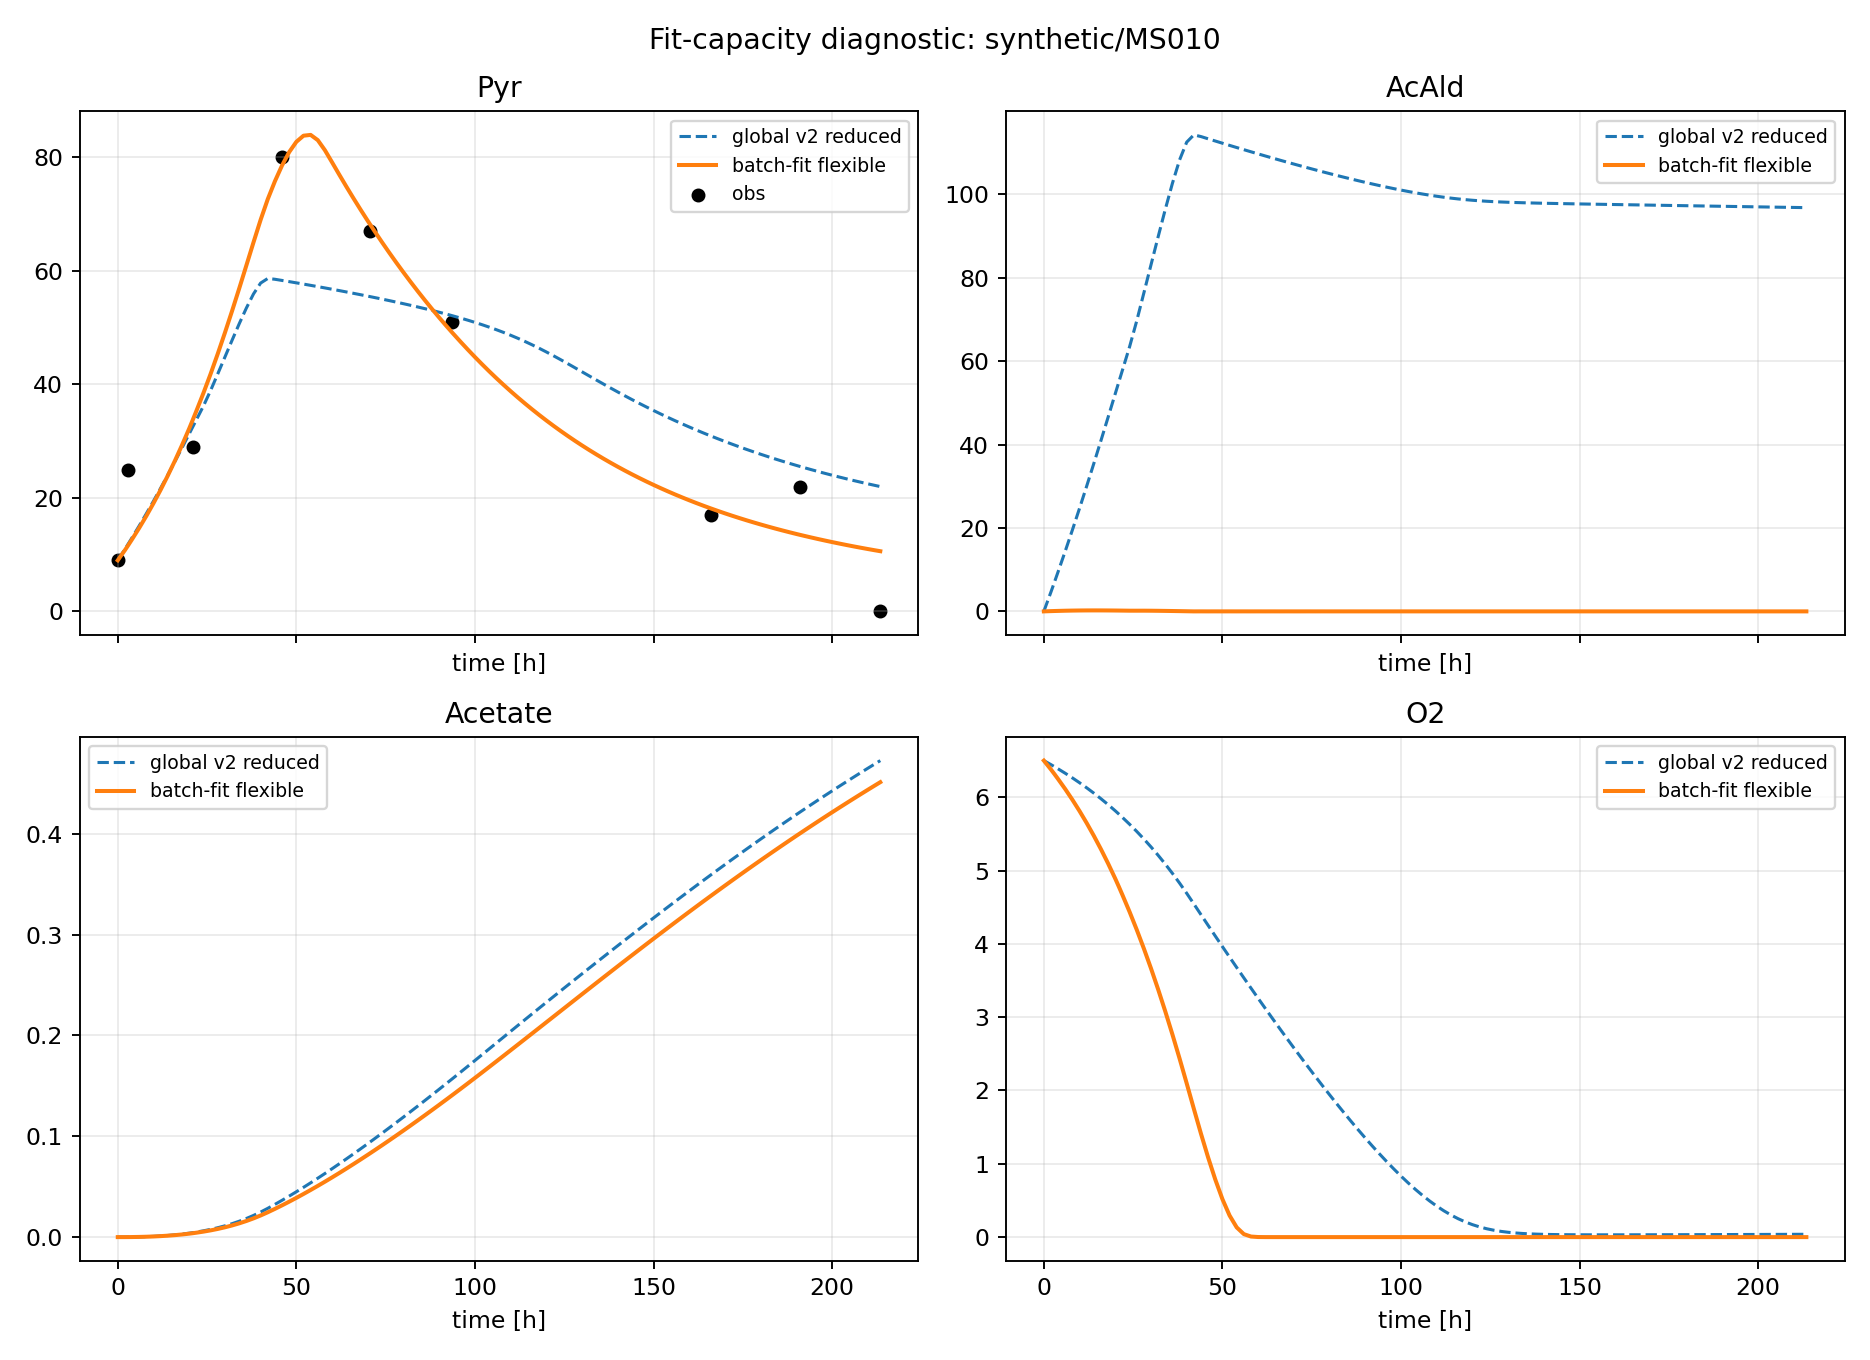

secondary_fit_capacity_synthetic_MS011.png


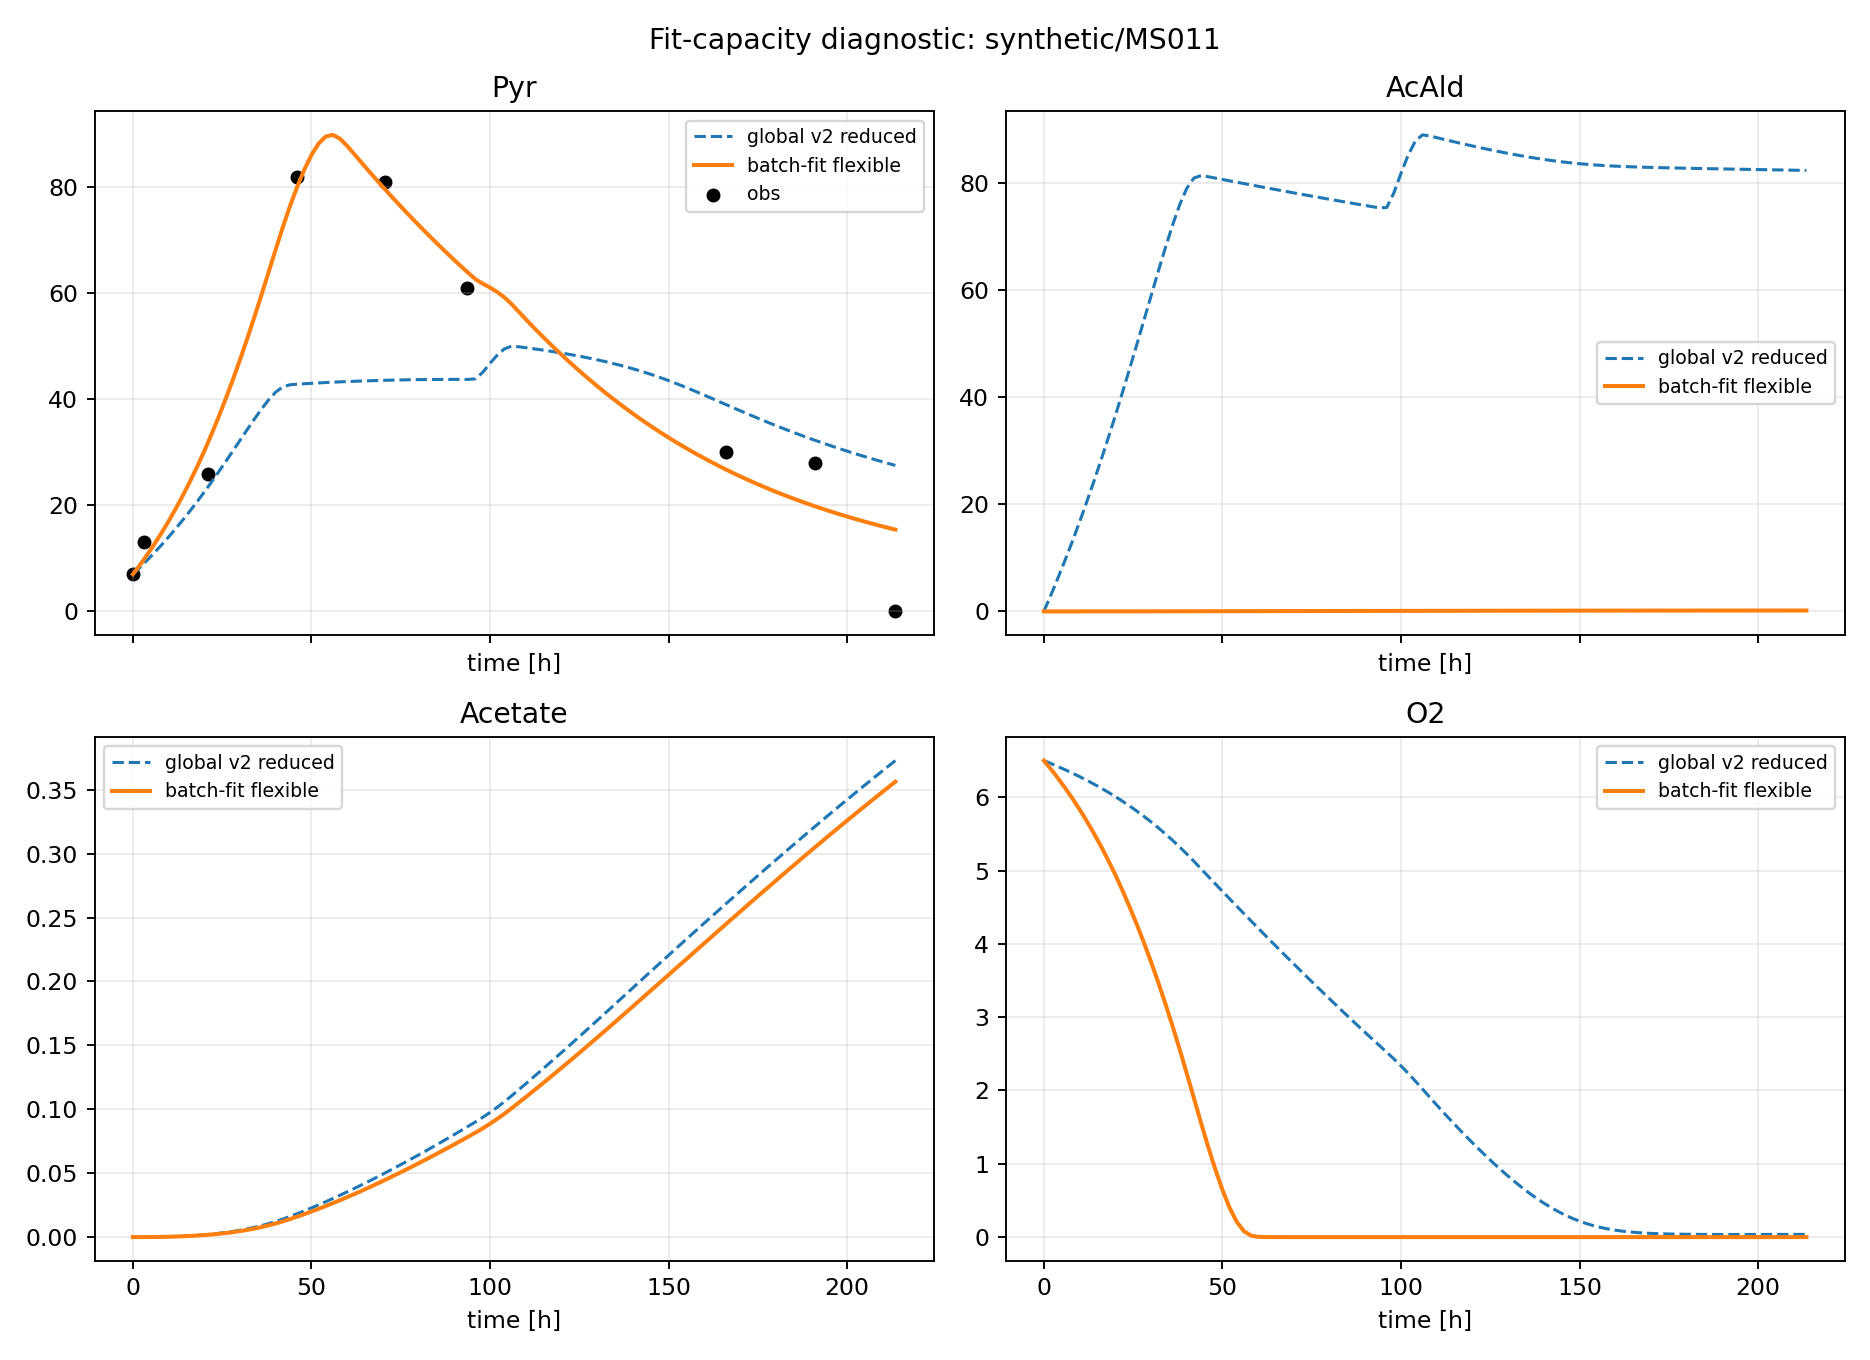

secondary_fit_capacity_synthetic_MS012.png


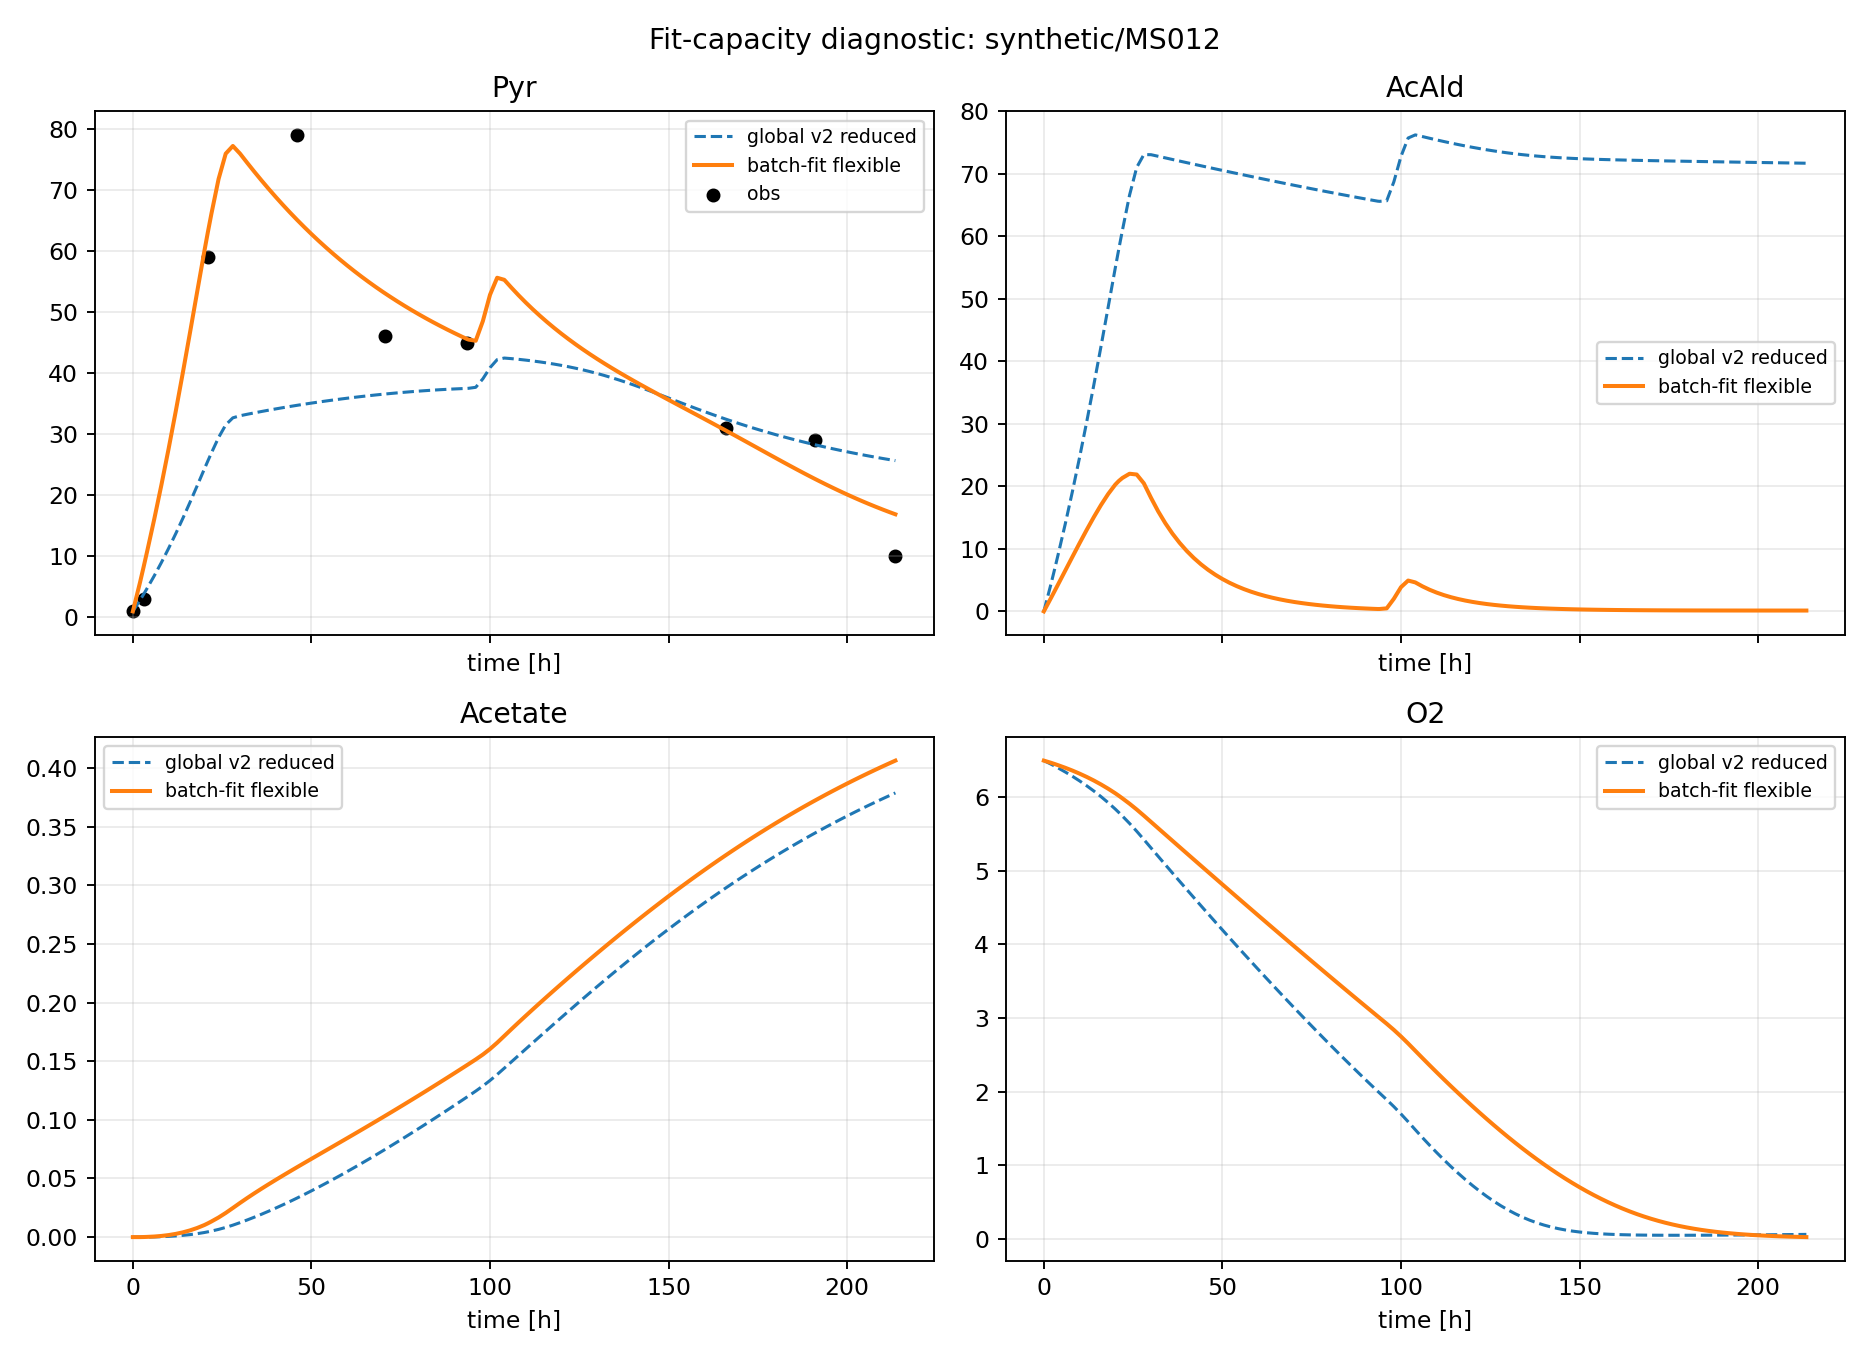

secondary_fit_capacity_synthetic_MS013.png


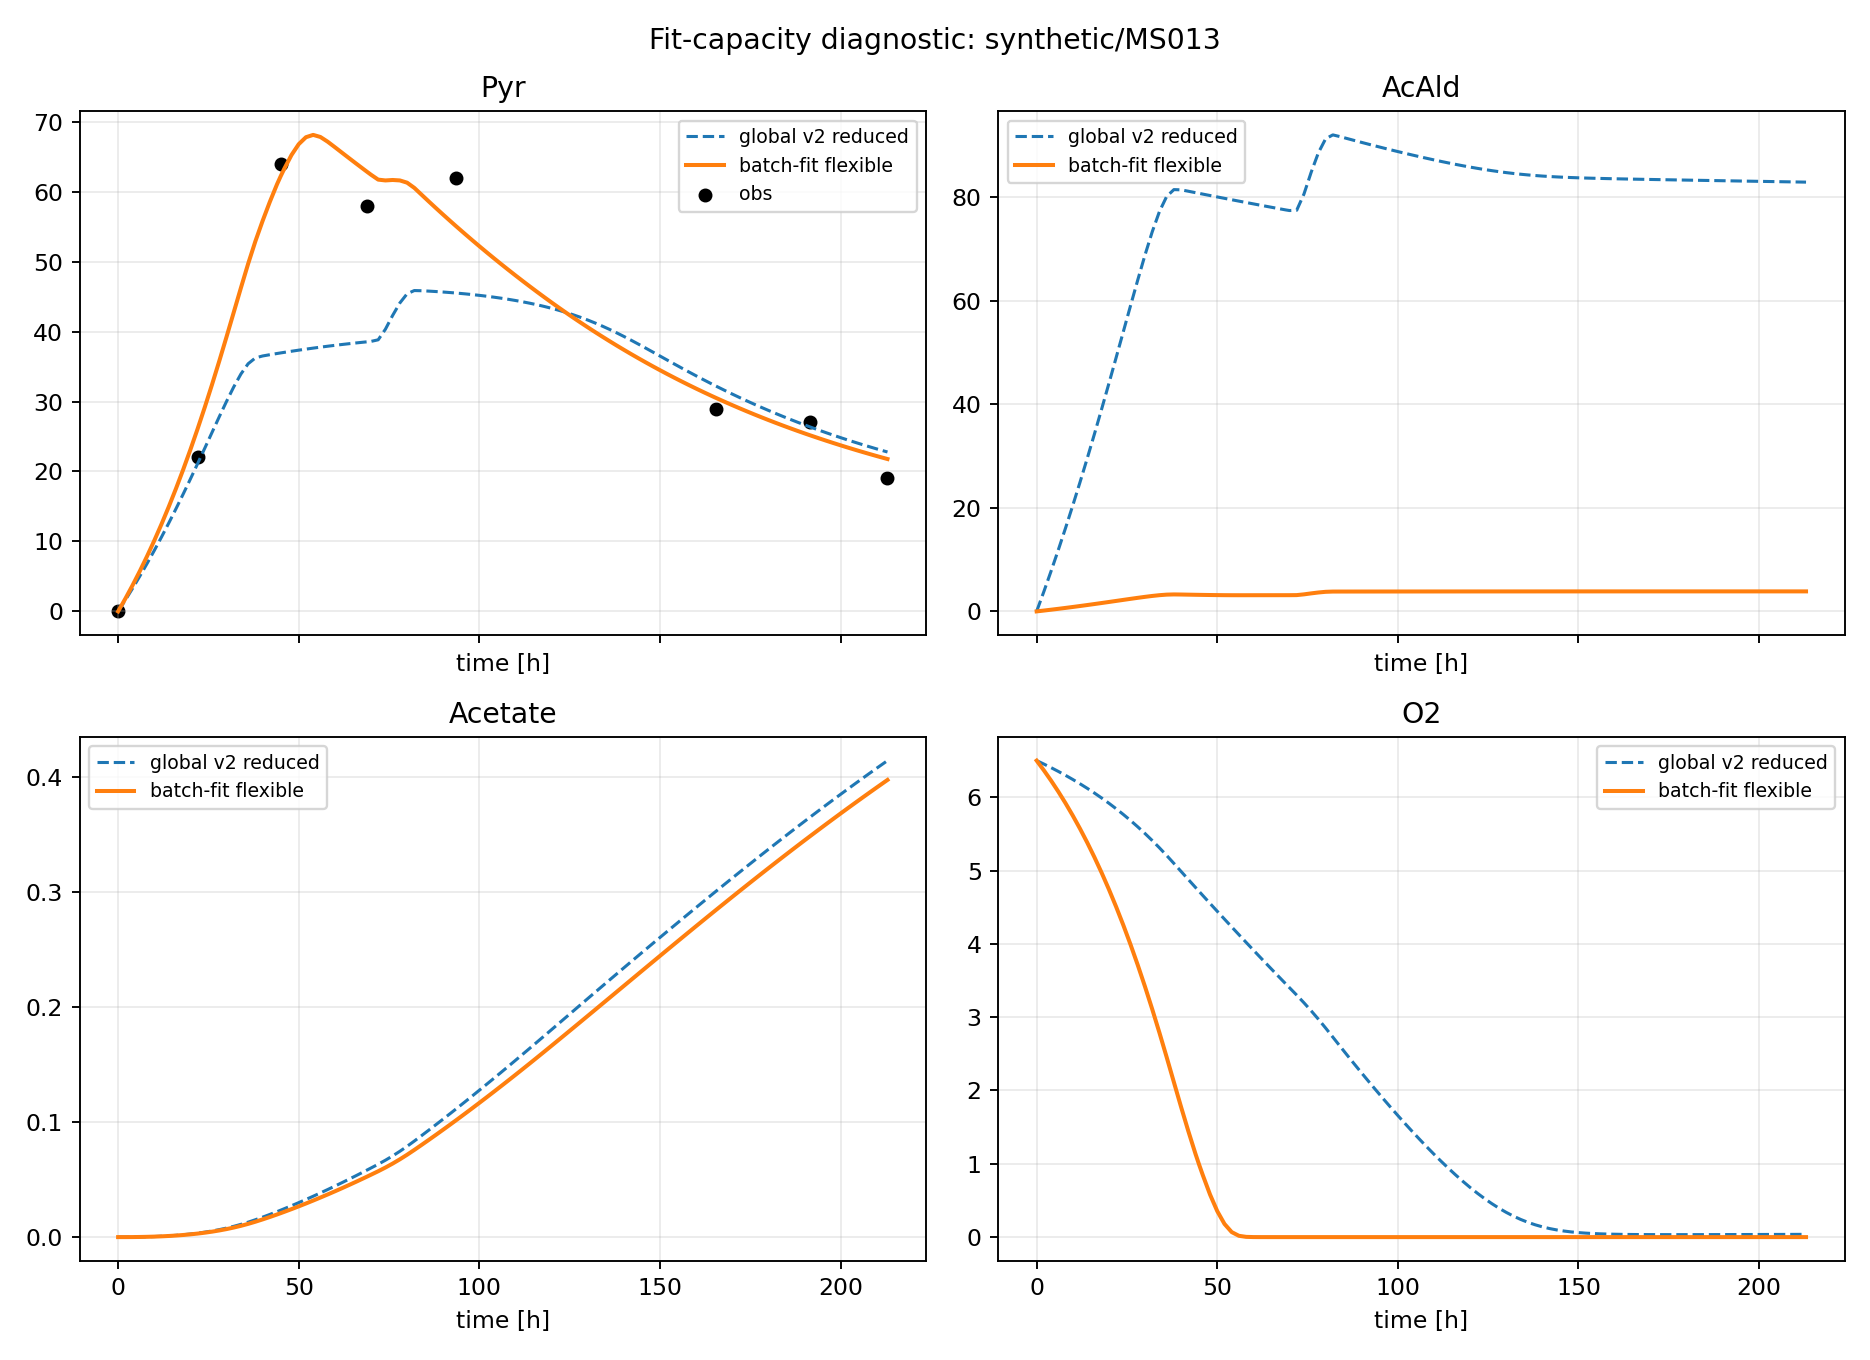

secondary_fit_capacity_synthetic_MS014.png


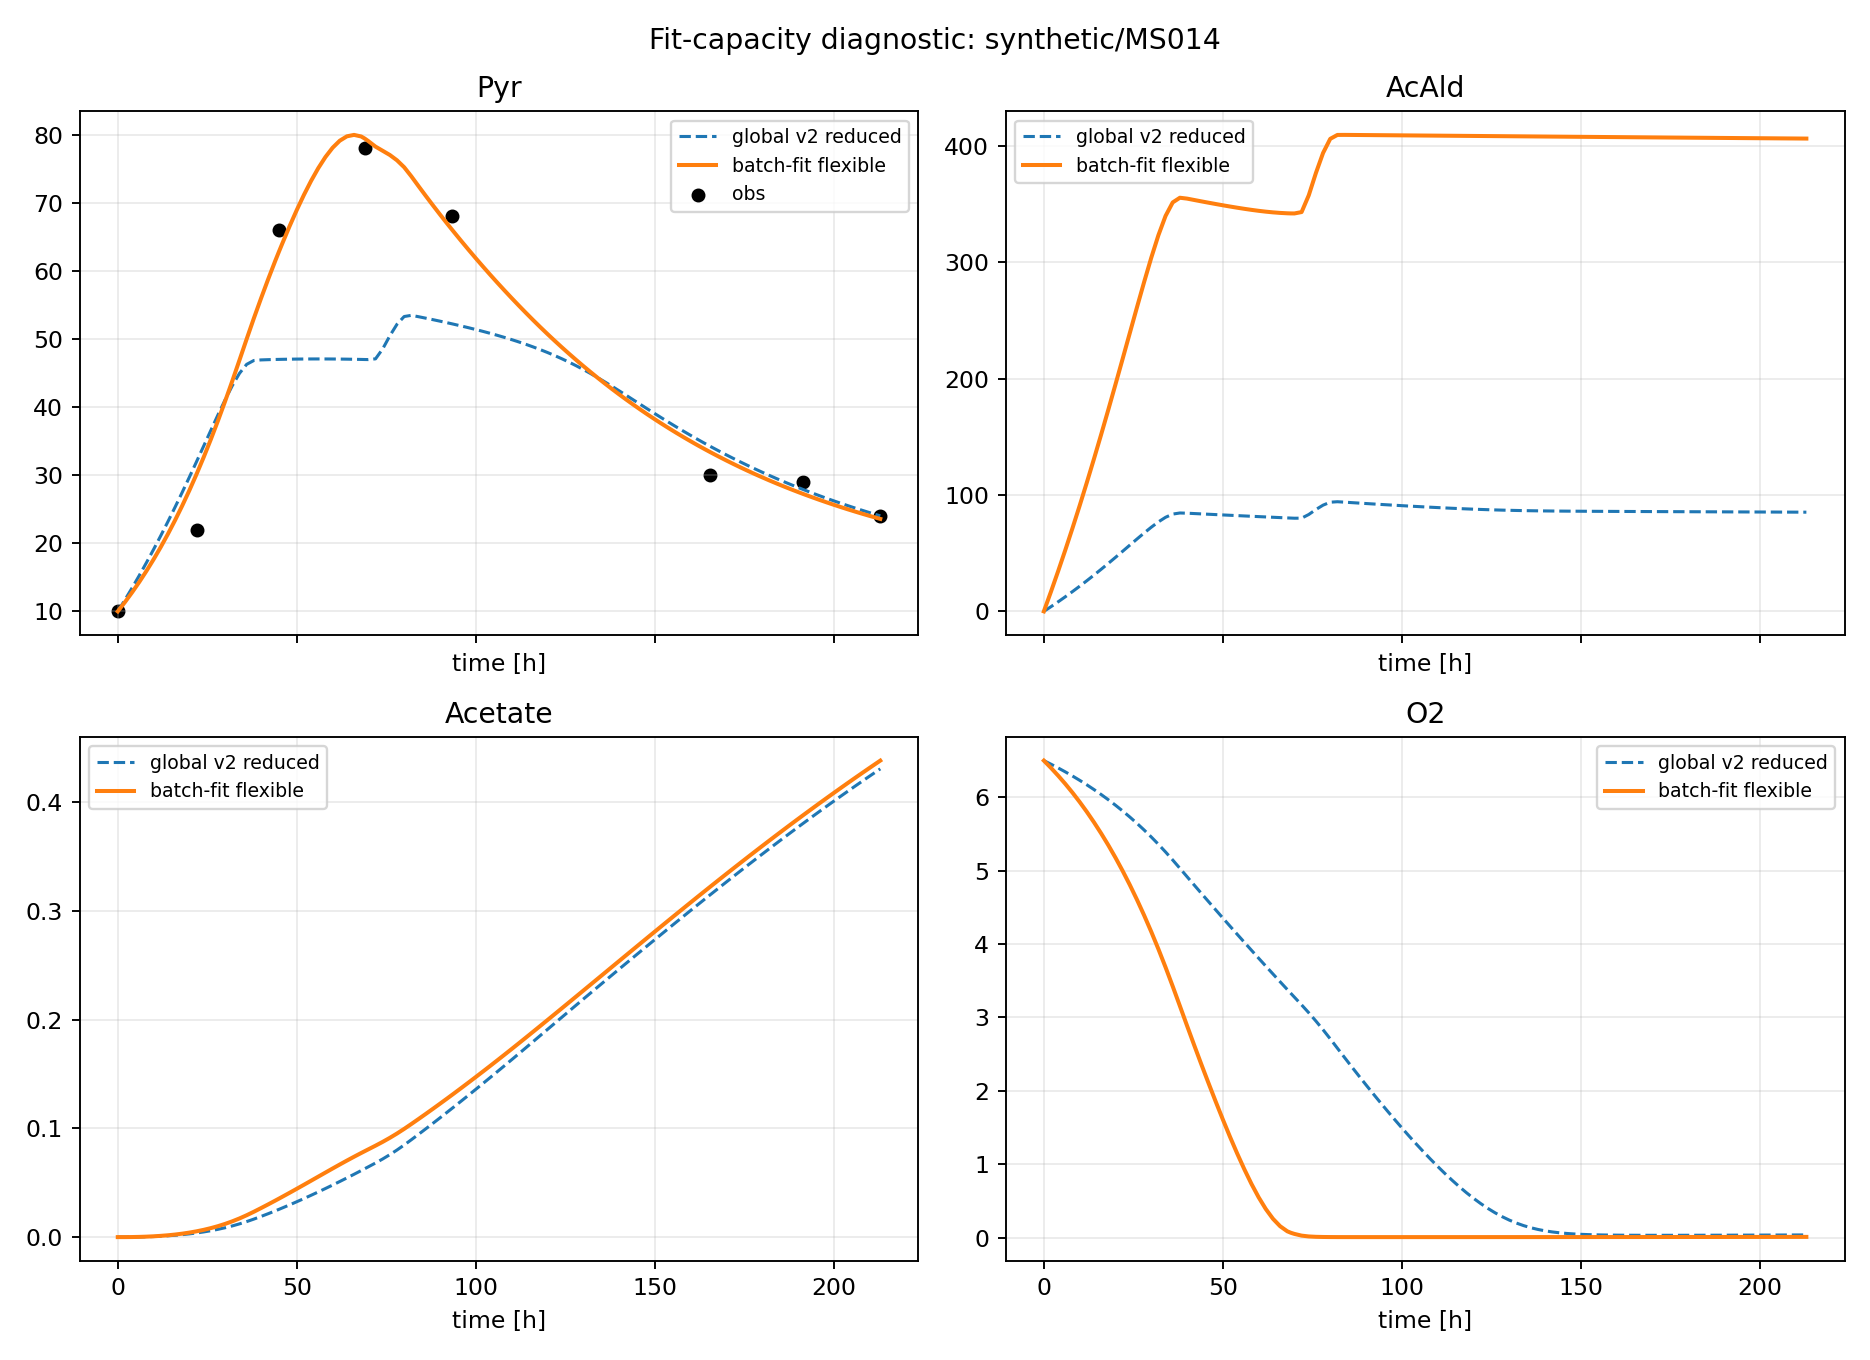

secondary_fit_capacity_synthetic_MS015.png


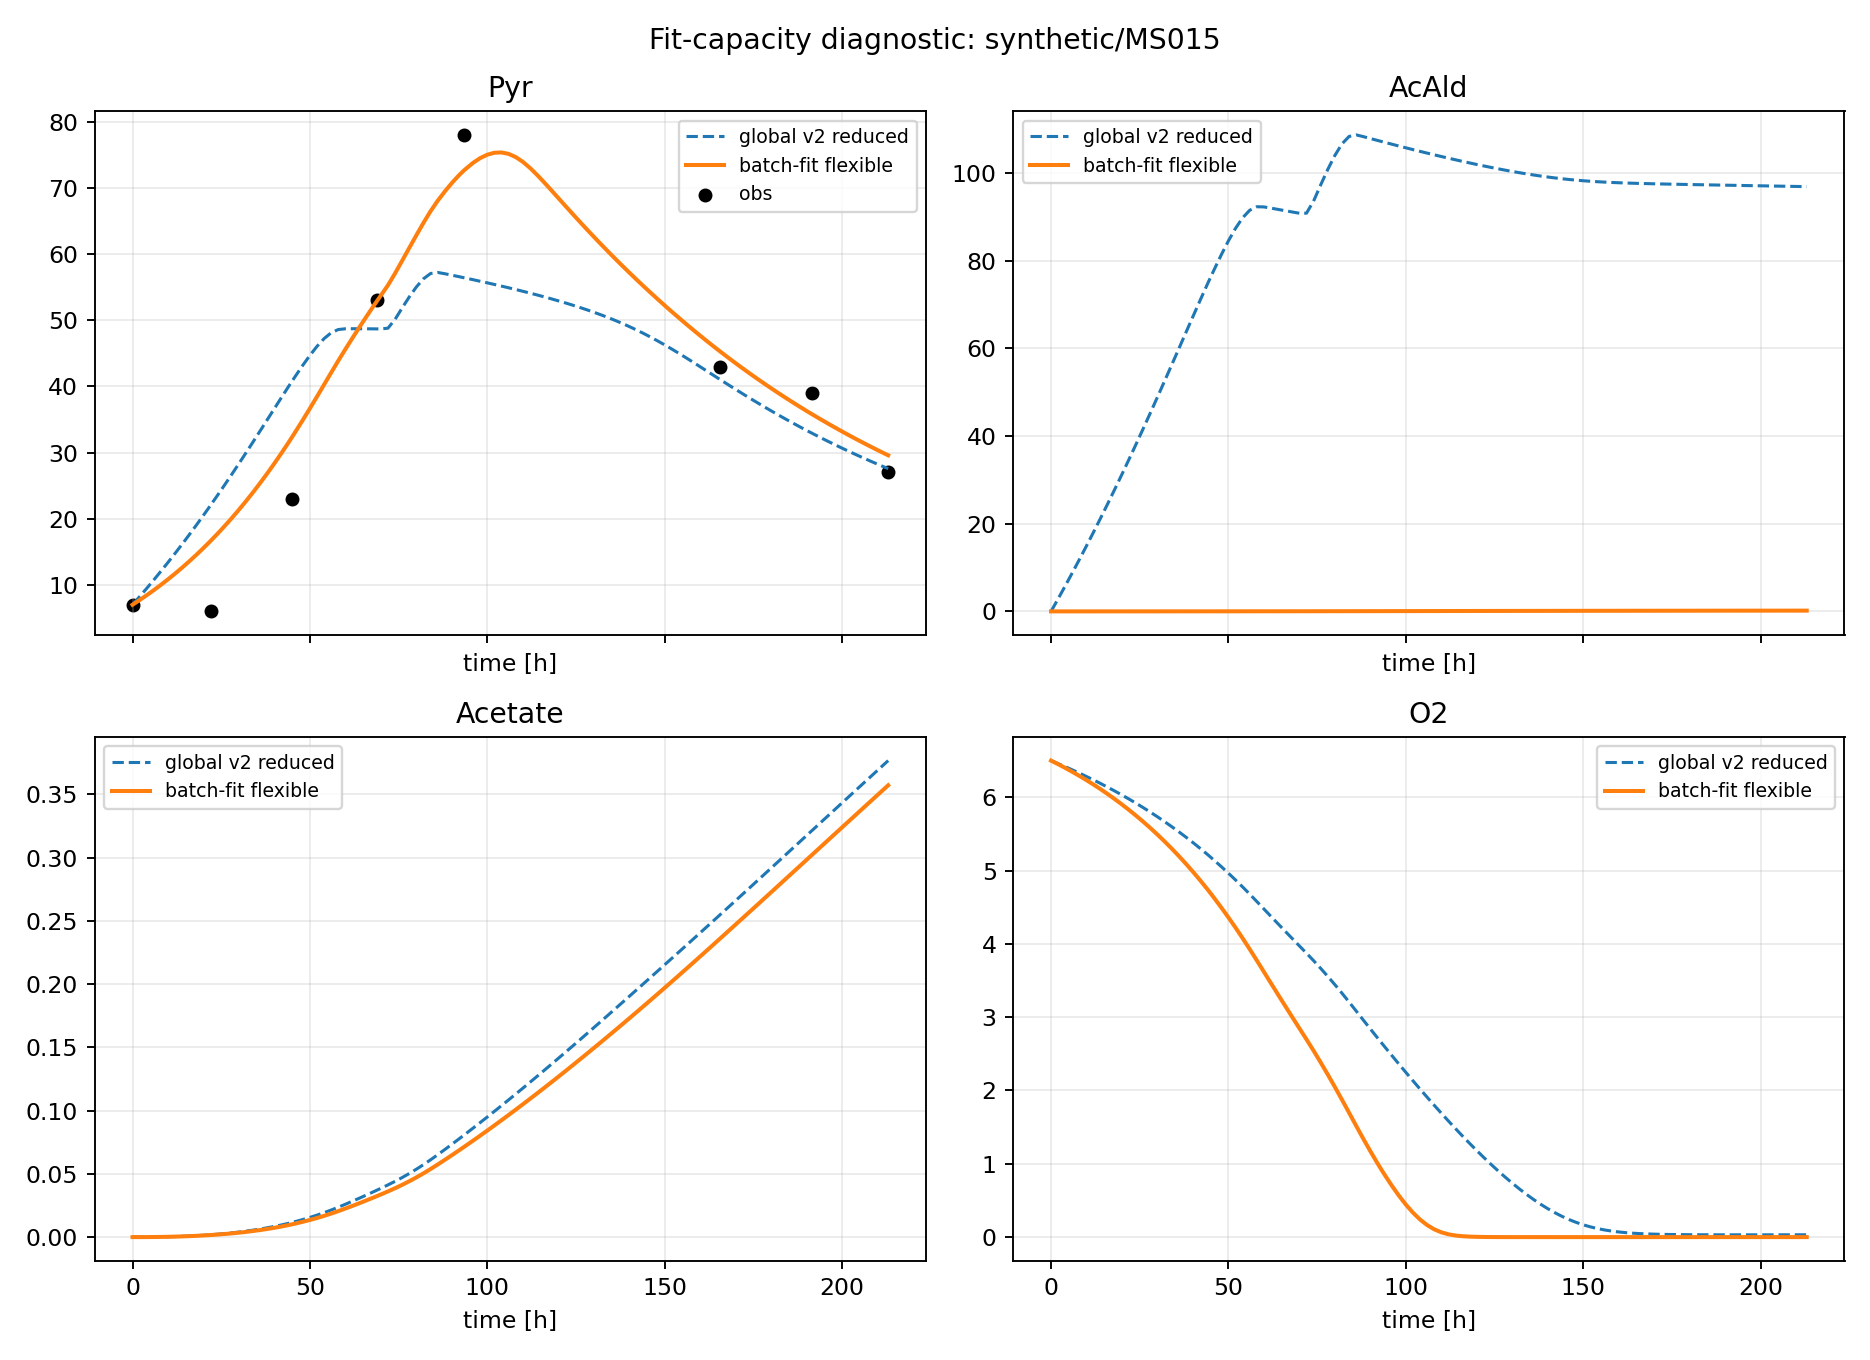

secondary_fit_capacity_synthetic_MS016.png


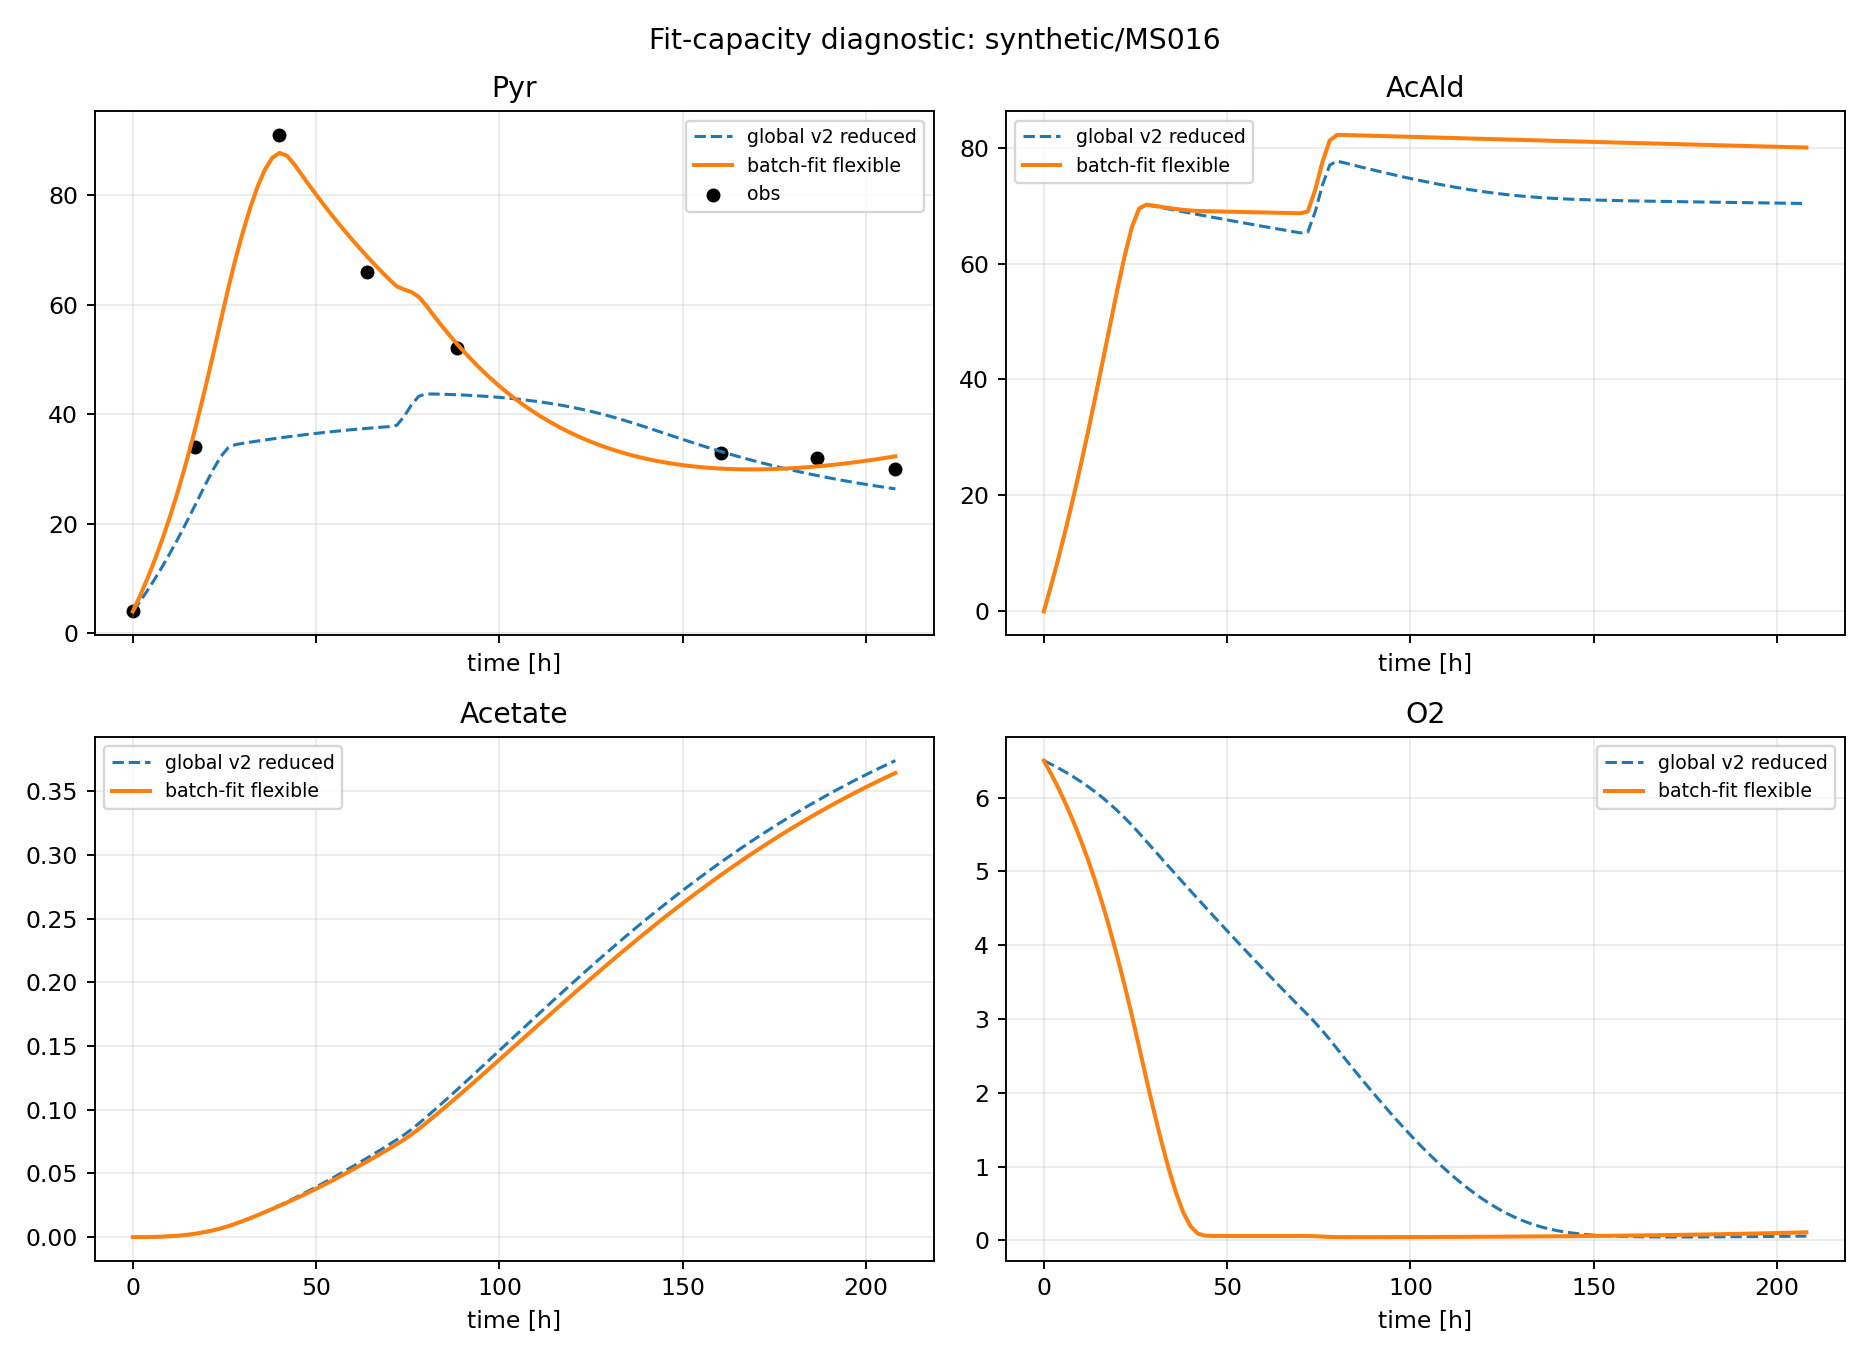

In [3]:
for png in sorted((RESULTS / 'plots').glob('secondary_fit_capacity_*.png')):
    print(png.name)
    display(Image(filename=str(png)))

## Report

In [4]:
print((RESULTS / 'secondary_fit_capacity_report.md').read_text(encoding='utf-8'))

# Secondary fit-capacity diagnostic

## Purpose

This diagnostic asks whether the secondary-state data can be fitted at all when parameter estimability and parameter transferability are deliberately relaxed.

The comparison separates three explanations for poor global curves:

- If per-batch fits are good but global fits are poor, the equation form has enough local flexibility but the parameters are not transferable across batches/media.
- If per-medium fits improve but per-batch fits improve much more, medium-specific effects are present but do not explain all variability.
- If even per-batch fits are poor, the secondary-state structure, core forcing, or observations are inconsistent with the ODE form.

## Fit summary

| fit_label                                     | success   |   status | message                                                 |   nfev |   n_parameters_fit |   n_batches |   n_residuals |   initial_wsse |   final_wsse |   wsse_per_residual |
|:-----------------------